In [2]:
# Load specifically the two files: customer_data.csv and device_data.csv
import pandas as pd
from pathlib import Path
import io
from IPython.display import display

data_dir = Path("C:/Users/ftrhack115/Downloads/hackaithon")
csv_files = sorted(data_dir.glob('*.csv'))

required = ['customer_data', 'device_data']
datasets = {}

if not csv_files:
    print(f'No CSV files found in {data_dir}')
else:
    stems = {p.stem: p for p in csv_files}
    for name in required:
        p = stems.get(name)
        if p is None:
            print(f'{name}.csv not found in {data_dir}')
            continue
        try:
            df = pd.read_csv(p)
        except Exception as e:
            print(f'Failed to read {p.name}: {e}')
            continue
        datasets[name] = df
        print(f'Loaded {p.name}: {df.shape[0]} rows x {df.shape[1]} columns')

    for name, df in datasets.items():
        print(f'\n=== {name} (shape={df.shape}) ===')
        display(df.head())

        buf = io.StringIO()
        df.info(buf=buf)
        print('Info:\n' + buf.getvalue())

        try:
            desc = df.describe(include='all').T
            print('Describe (transposed):')
            display(desc)
        except Exception as e:
            print('Describe failed:', e)

        print('Missing values per column:')
        print(df.isnull().sum())

        num = df.select_dtypes(include=['number'])
        if not num.empty:
            print('Numeric summary:')
            display(num.describe().T)

# Expose the two datasets as variables
customer_data = datasets.get('customer_data')
device_data = datasets.get('device_data')

Loaded customer_data.csv: 100000 rows x 9 columns
Loaded device_data.csv: 300000 rows x 8 columns

=== customer_data (shape=(100000, 9)) ===


,customer_id,clv_decile,churn_risk,current_bb_speed,network_activity,account_tenure,time_of_last_broadband_upgrade,broadband_type,customer_segment
0,3814,8,0,500mb,heavy,63,2016-12-20,Fiber,Foolproof Followers
1,99184,9,0,1Gig,medium,80,2025-02-01,Fiber,Settled Simplifiers
2,80738,2,0,1Gig,heavy,115,2023-01-24,Fiber,Settled Simplifiers
3,65675,8,0,1Gig,medium,78,2018-02-17,Fiber,Aspirational Adopters
4,53671,10,0,1Gig,medium,48,2022-04-12,Fiber,Settled Simplifiers


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column                          Non-Null Count   Dtype 
---  ------                          --------------   ----- 
 0   customer_id                     100000 non-null  int64 
 1   clv_decile                      100000 non-null  int64 
 2   churn_risk                      100000 non-null  int64 
 3   current_bb_speed                100000 non-null  object
 4   network_activity                100000 non-null  object
 5   account_tenure                  100000 non-null  int64 
 6   time_of_last_broadband_upgrade  100000 non-null  object
 7   broadband_type                  100000 non-null  object
 8   customer_segment                100000 non-null  object
dtypes: int64(4), object(5)
memory usage: 6.9+ MB

Describe (transposed):


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,100000.0,NaN,NaN,NaN,50000.5,28867.657797,1.0,25000.75,50000.5,75000.25,100000.0
clv_decile,100000.0,NaN,NaN,NaN,5.5,2.872296,1.0,3.0,5.5,8.0,10.0
churn_risk,100000.0,NaN,NaN,NaN,0.01997,0.139898,0.0,0.0,0.0,0.0,1.0
current_bb_speed,100000,4,1Gig,36106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
network_activity,100000,3,medium,49932,NaN,NaN,NaN,NaN,NaN,NaN,NaN
account_tenure,100000.0,NaN,NaN,NaN,60.23428,34.611814,1.0,30.0,60.0,90.0,120.0
time_of_last_broadband_upgrade,100000,3593,2023-09-02,49,NaN,NaN,NaN,NaN,NaN,NaN,NaN
broadband_type,100000,2,Fiber,89556,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_segment,100000,5,Settled Simplifiers,36201,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing values per column:
customer_id                       0
clv_decile                        0
churn_risk                        0
current_bb_speed                  0
network_activity                  0
account_tenure                    0
time_of_last_broadband_upgrade    0
broadband_type                    0
customer_segment                  0
dtype: int64
Numeric summary:


...

,customer_id,serial_number,device_model,device_status,isp,ship_date,last_alive_date,sqs_score
0,3814,2787233841,Eero 6+,Provisioned,Frontier Communications,2022-11-15,2025-11-17,3
1,99184,4451722011,Eero 6,StockShelved,Frontier Communications,2022-04-08,2025-11-17,3
2,80738,9456782759,Eero 6+,StockShelved,Frontier Communications,2022-10-01,2025-09-20,3
3,65675,6068930073,Eero 6,Provisioned,Frontier Communications,2022-07-07,2025-11-17,3
4,53671,2374028048,Eero 6,Provisioned,Frontier Communications,2021-12-06,2025-11-17,3


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   customer_id      300000 non-null  int64 
 1   serial_number    300000 non-null  int64 
 2   device_model     300000 non-null  object
 3   device_status    300000 non-null  object
 4   isp              300000 non-null  object
 5   ship_date        300000 non-null  object
 6   last_alive_date  300000 non-null  object
 7   sqs_score        300000 non-null  int64 
dtypes: int64(3), object(5)
memory usage: 18.3+ MB

Describe (transposed):


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,300000.0,NaN,NaN,NaN,50060.68481,28834.98962,1.0,25037.75,50128.0,75089.0,100000.0
serial_number,300000.0,NaN,NaN,NaN,4997243010.38042,2888309365.349311,95245.0,2496256292.75,4990889776.0,7495092643.5,9999948426.0
device_model,300000,4,Eero 6+,106637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_status,300000,4,Provisioned,180103,NaN,NaN,NaN,NaN,NaN,NaN,NaN
isp,300000,2,Frontier Communications,270065,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ship_date,300000,457,2022-06-07,735,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_alive_date,300000,1812,2025-11-17,180263,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sqs_score,300000.0,NaN,NaN,NaN,2.86471,0.444905,0.0,3.0,3.0,3.0,3.0


Missing values per column:
customer_id        0
serial_number      0
device_model       0
device_status      0
isp                0
ship_date          0
last_alive_date    0
sqs_score          0
dtype: int64
Numeric summary:


,count,mean,std,min,25%,50%,75%,max
customer_id,300000.0,5.006068e+04,2.883499e+04,1.0,2.503775e+04,5.012800e+04,7.508900e+04,1.000000e+05
serial_number,300000.0,4.997243e+09,2.888309e+09,95245.0,2.496256e+09,4.990890e+09,7.495093e+09,9.999948e+09
sqs_score,300000.0,2.864710e+00,4.449052e-01,0.0,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00


In [3]:
def show_uniques_counts(df, cols):
    """
    Show unique values and value counts + percentage share for one or more columns in df.
    cols: str or list-like of column names
    Returns a dict mapping column -> DataFrame with 'count' and 'pct' columns for found columns.
    """
    if isinstance(cols, str):
        cols = [cols]
    results = {}
    total = len(df)
    for col in cols:
        print(f"Column: {col!r}")
        if col in df.columns:
            print("Unique values:", df[col].unique().tolist())
            print("\nValue counts and percentage share:")
            vc = df[col].value_counts(dropna=False)
            pct = df[col].value_counts(dropna=False, normalize=True) * 100
            combined = pd.DataFrame({'count': vc, 'pct': pct.round(2)})
            display(combined)
            results[col] = combined
        else:
            print(f"Column {col!r} not found in dataframe")
        print('-' * 40)
    return results

In [4]:
def unique_count(df, col, include_na=False, method='nunique'):
    """
    Return the number of unique values for df[col].
    
    Parameters
    - df: pandas.DataFrame
    - col: column name (str)
    - include_na: if True count NaN as a distinct value
    - method: 'nunique' (uses Series.nunique) or 'len_unique' (uses len(series.unique()))
    
    Returns
    - int: number of unique values (NaN counted when include_na=True)
    """
    if col not in df.columns:
        raise KeyError(f"Column {col!r} not found in dataframe")
    if method == 'nunique':
        return int(df[col].nunique(dropna=not include_na))
    elif method == 'len_unique':
        if include_na:
            return int(len(df[col].unique()))
        else:
            return int(len(pd.unique(df[col].dropna())))
    else:
        raise ValueError("method must be 'nunique' or 'len_unique'")


In [5]:
unique_count(device_data, 'customer_id')

100000

In [6]:
show_uniques_counts(customer_data, ['broadband_type', 'network_activity'])

Column: 'broadband_type'
Unique values: ['Fiber', 'Copper']

Value counts and percentage share:


,count,pct
broadband_type,,
Fiber,89556,89.56
Copper,10444,10.44


----------------------------------------
Column: 'network_activity'
Unique values: ['heavy', 'medium', 'light']

Value counts and percentage share:


,count,pct
network_activity,,
medium,49932,49.93
heavy,25172,25.17
light,24896,24.90


----------------------------------------


{'broadband_type':                 count    pct
 broadband_type              
 Fiber           89556  89.56
 Copper          10444  10.44,
 'network_activity':                   count    pct
 network_activity              
 medium            49932  49.93
 heavy             25172  25.17
 light             24896  24.90}

In [7]:
show_uniques_counts(device_data, ['device_model', 'device_status', 'isp'])

Column: 'device_model'
Unique values: ['Eero 6+', 'Eero 6', 'Eero Pro 6', 'Eero Pro 6E']

Value counts and percentage share:


,count,pct
device_model,,
Eero 6+,106637,35.55
Eero Pro 6,91094,30.36
Eero 6,65202,21.73
Eero Pro 6E,37067,12.36


----------------------------------------
Column: 'device_status'
Unique values: ['Provisioned', 'StockShelved', 'PendingReturn', 'CustShipped']

Value counts and percentage share:


,count,pct
device_status,,
Provisioned,180103,60.03
StockShelved,74934,24.98
PendingReturn,30015,10.01
CustShipped,14948,4.98


----------------------------------------
Column: 'isp'
Unique values: ['Frontier Communications', 'Not Frontier ISP']

Value counts and percentage share:


,count,pct
isp,,
Frontier Communications,270065,90.02
Not Frontier ISP,29935,9.98


----------------------------------------


{'device_model':                count    pct
 device_model               
 Eero 6+       106637  35.55
 Eero Pro 6     91094  30.36
 Eero 6         65202  21.73
 Eero Pro 6E    37067  12.36,
 'device_status':                 count    pct
 device_status               
 Provisioned    180103  60.03
 StockShelved    74934  24.98
 PendingReturn   30015  10.01
 CustShipped     14948   4.98,
 'isp':                           count    pct
 isp                                   
 Frontier Communications  270065  90.02
 Not Frontier ISP          29935   9.98}

In [8]:
customer_data.head()

,customer_id,clv_decile,churn_risk,current_bb_speed,network_activity,account_tenure,time_of_last_broadband_upgrade,broadband_type,customer_segment
0,3814,8,0,500mb,heavy,63,2016-12-20,Fiber,Foolproof Followers
1,99184,9,0,1Gig,medium,80,2025-02-01,Fiber,Settled Simplifiers
2,80738,2,0,1Gig,heavy,115,2023-01-24,Fiber,Settled Simplifiers
3,65675,8,0,1Gig,medium,78,2018-02-17,Fiber,Aspirational Adopters
4,53671,10,0,1Gig,medium,48,2022-04-12,Fiber,Settled Simplifiers


In [9]:
device_data.head()

,customer_id,serial_number,device_model,device_status,isp,ship_date,last_alive_date,sqs_score
0,3814,2787233841,Eero 6+,Provisioned,Frontier Communications,2022-11-15,2025-11-17,3
1,99184,4451722011,Eero 6,StockShelved,Frontier Communications,2022-04-08,2025-11-17,3
2,80738,9456782759,Eero 6+,StockShelved,Frontier Communications,2022-10-01,2025-09-20,3
3,65675,6068930073,Eero 6,Provisioned,Frontier Communications,2022-07-07,2025-11-17,3
4,53671,2374028048,Eero 6,Provisioned,Frontier Communications,2021-12-06,2025-11-17,3


In [10]:
# Perform inner join on 'customer_id'
merged_data = pd.merge(device_data, customer_data, on='customer_id', how='left')
print(f"Merged shape: {merged_data.shape}")
display(merged_data.head())

Merged shape: (300000, 16)


,customer_id,serial_number,device_model,device_status,isp,ship_date,last_alive_date,sqs_score,clv_decile,churn_risk,current_bb_speed,network_activity,account_tenure,time_of_last_broadband_upgrade,broadband_type,customer_segment
0,3814,2787233841,Eero 6+,Provisioned,Frontier Communications,2022-11-15,2025-11-17,3,8,0,500mb,heavy,63,2016-12-20,Fiber,Foolproof Followers
1,99184,4451722011,Eero 6,StockShelved,Frontier Communications,2022-04-08,2025-11-17,3,9,0,1Gig,medium,80,2025-02-01,Fiber,Settled Simplifiers
2,80738,9456782759,Eero 6+,StockShelved,Frontier Communications,2022-10-01,2025-09-20,3,2,0,1Gig,heavy,115,2023-01-24,Fiber,Settled Simplifiers
3,65675,6068930073,Eero 6,Provisioned,Frontier Communications,2022-07-07,2025-11-17,3,8,0,1Gig,medium,78,2018-02-17,Fiber,Aspirational Adopters
4,53671,2374028048,Eero 6,Provisioned,Frontier Communications,2021-12-06,2025-11-17,3,10,0,1Gig,medium,48,2022-04-12,Fiber,Settled Simplifiers


In [11]:
# ensure last_alive_date is datetime and compute days from that date to today
merged_data['last_alive_date'] = pd.to_datetime(merged_data['last_alive_date'], errors='coerce')
today = pd.Timestamp.now().normalize()
merged_data['days_since_last_alive'] = (today - merged_data['last_alive_date']).dt.days

In [12]:
merged_data.head()

,customer_id,serial_number,device_model,device_status,isp,ship_date,last_alive_date,sqs_score,clv_decile,churn_risk,current_bb_speed,network_activity,account_tenure,time_of_last_broadband_upgrade,broadband_type,customer_segment,days_since_last_alive
0,3814,2787233841,Eero 6+,Provisioned,Frontier Communications,2022-11-15,2025-11-17,3,8,0,500mb,heavy,63,2016-12-20,Fiber,Foolproof Followers,1
1,99184,4451722011,Eero 6,StockShelved,Frontier Communications,2022-04-08,2025-11-17,3,9,0,1Gig,medium,80,2025-02-01,Fiber,Settled Simplifiers,1
2,80738,9456782759,Eero 6+,StockShelved,Frontier Communications,2022-10-01,2025-09-20,3,2,0,1Gig,heavy,115,2023-01-24,Fiber,Settled Simplifiers,59
3,65675,6068930073,Eero 6,Provisioned,Frontier Communications,2022-07-07,2025-11-17,3,8,0,1Gig,medium,78,2018-02-17,Fiber,Aspirational Adopters,1
4,53671,2374028048,Eero 6,Provisioned,Frontier Communications,2021-12-06,2025-11-17,3,10,0,1Gig,medium,48,2022-04-12,Fiber,Settled Simplifiers,1


In [13]:
show_uniques_counts(merged_data, ['isp'])

Column: 'isp'
Unique values: ['Frontier Communications', 'Not Frontier ISP']

Value counts and percentage share:


,count,pct
isp,,
Frontier Communications,270065,90.02
Not Frontier ISP,29935,9.98


----------------------------------------


{'isp':                           count    pct
 isp                                   
 Frontier Communications  270065  90.02
 Not Frontier ISP          29935   9.98}

In [14]:
# Count distinct serials per customer (include customers with zero devices)
counts_per_customer = device_data.groupby('customer_id')['serial_number'].nunique()
all_customers = customer_data['customer_id'].unique()
counts_per_customer = counts_per_customer.reindex(all_customers, fill_value=0)

total_customers = len(all_customers)

# Count distinct customers with 0..6 unique serials and show counts + percentages
customers_per_bucket = counts_per_customer.value_counts().reindex(range(0, 7), fill_value=0).sort_index()

bucket_df = pd.DataFrame({
    'customers': customers_per_bucket.astype(int),
    'pct_of_customers': (customers_per_bucket / total_customers * 100).round(2)
}, index=customers_per_bucket.index)
bucket_df.index.name = 'num_serials'

display(bucket_df)

,customers,pct_of_customers
num_serials,,
0,0,0.00
1,50000,50.00
2,444,0.44
3,5468,5.47
4,10647,10.65
5,15020,15.02
6,13927,13.93


In [15]:
# create new column based on days_since_last_alive: >30 -> 'inactive', else 'active' (NaN -> 'unknown')
merged_data['last_alive_status'] = merged_data['days_since_last_alive'].apply(
    lambda x: 'unknown' if pd.isna(x) else ('inactive' if x > 30 else 'active')
)

In [16]:
show_uniques_counts(merged_data, ['last_alive_status'])

Column: 'last_alive_status'
Unique values: ['active', 'inactive']

Value counts and percentage share:


,count,pct
last_alive_status,,
active,189522,63.17
inactive,110478,36.83


----------------------------------------


{'last_alive_status':                     count    pct
 last_alive_status               
 active             189522  63.17
 inactive           110478  36.83}

In [17]:
merged_data.head()

,customer_id,serial_number,device_model,device_status,isp,ship_date,last_alive_date,sqs_score,clv_decile,churn_risk,current_bb_speed,network_activity,account_tenure,time_of_last_broadband_upgrade,broadband_type,customer_segment,days_since_last_alive,last_alive_status
0,3814,2787233841,Eero 6+,Provisioned,Frontier Communications,2022-11-15,2025-11-17,3,8,0,500mb,heavy,63,2016-12-20,Fiber,Foolproof Followers,1,active
1,99184,4451722011,Eero 6,StockShelved,Frontier Communications,2022-04-08,2025-11-17,3,9,0,1Gig,medium,80,2025-02-01,Fiber,Settled Simplifiers,1,active
2,80738,9456782759,Eero 6+,StockShelved,Frontier Communications,2022-10-01,2025-09-20,3,2,0,1Gig,heavy,115,2023-01-24,Fiber,Settled Simplifiers,59,inactive
3,65675,6068930073,Eero 6,Provisioned,Frontier Communications,2022-07-07,2025-11-17,3,8,0,1Gig,medium,78,2018-02-17,Fiber,Aspirational Adopters,1,active
4,53671,2374028048,Eero 6,Provisioned,Frontier Communications,2021-12-06,2025-11-17,3,10,0,1Gig,medium,48,2022-04-12,Fiber,Settled Simplifiers,1,active


In [18]:
show_uniques_counts(merged_data, ['isp'])

Column: 'isp'
Unique values: ['Frontier Communications', 'Not Frontier ISP']

Value counts and percentage share:


,count,pct
isp,,
Frontier Communications,270065,90.02
Not Frontier ISP,29935,9.98


----------------------------------------


{'isp':                           count    pct
 isp                                   
 Frontier Communications  270065  90.02
 Not Frontier ISP          29935   9.98}

In [19]:
# contingency matrix between last_alive_status and isp (counts + row/column percentages)
ct_counts = pd.crosstab(merged_data['last_alive_status'], merged_data['isp'], dropna=False)
ct_row_pct = (ct_counts.div(ct_counts.sum(axis=1), axis=0) * 100).round(2)

print("Counts:")
display(ct_counts)

print("\nRow-wise % (each row sums to ~100):")
display(ct_row_pct)

Counts:


isp,Frontier Communications,Not Frontier ISP
last_alive_status,,
active,170550,18972
inactive,99515,10963



Row-wise % (each row sums to ~100):


isp,Frontier Communications,Not Frontier ISP
last_alive_status,,
active,89.99,10.01
inactive,90.08,9.92


In [20]:
# Filter merged_data for rows where isp is 'Frontier Communications' and last_alive_status is 'active'
fc_active = merged_data[
    (merged_data['isp'] == 'Frontier Communications') &
    (merged_data['last_alive_status'] == 'active')
]
print(f"Filtered shape: {fc_active.shape}")
display(fc_active.head())

Filtered shape: (170550, 18)


,customer_id,serial_number,device_model,device_status,isp,ship_date,last_alive_date,sqs_score,clv_decile,churn_risk,current_bb_speed,network_activity,account_tenure,time_of_last_broadband_upgrade,broadband_type,customer_segment,days_since_last_alive,last_alive_status
0,3814,2787233841,Eero 6+,Provisioned,Frontier Communications,2022-11-15,2025-11-17,3,8,0,500mb,heavy,63,2016-12-20,Fiber,Foolproof Followers,1,active
1,99184,4451722011,Eero 6,StockShelved,Frontier Communications,2022-04-08,2025-11-17,3,9,0,1Gig,medium,80,2025-02-01,Fiber,Settled Simplifiers,1,active
3,65675,6068930073,Eero 6,Provisioned,Frontier Communications,2022-07-07,2025-11-17,3,8,0,1Gig,medium,78,2018-02-17,Fiber,Aspirational Adopters,1,active
4,53671,2374028048,Eero 6,Provisioned,Frontier Communications,2021-12-06,2025-11-17,3,10,0,1Gig,medium,48,2022-04-12,Fiber,Settled Simplifiers,1,active
8,75155,7343122007,Eero Pro 6,StockShelved,Frontier Communications,2022-01-13,2025-11-17,3,7,0,2Gig,light,76,2020-01-26,Fiber,Peak Performers,1,active


In [21]:
import numpy as np

# Define rule-based conditions (ordered by priority)
conds = [
    # High churn & high CLV -> Speed upgrade with new device
    (fc_active['churn_risk'] == 1) & (fc_active['clv_decile'] >= 5),
    # High churn & very poor device experience -> Proactive Replace with no speed upgrade
    (fc_active['churn_risk'] == 1) & (fc_active['sqs_score'] <= 1),
    # Other churn cases -> speed upgrade (same device first)
    (fc_active['churn_risk'] == 1),
    # Very poor device experience (non-churn) -> proactive replace
    (fc_active['sqs_score'] <= 1),
    # Heavy users or performance-oriented segments -> speed upgrade
    (fc_active['network_activity'].str.lower().eq('heavy')) |
        (fc_active['customer_segment'].isin(['Peak Performers', 'Aspirational Adopters'])),
    # Very high CLV (reward) -> speed + new device
    (fc_active['clv_decile'] >= 9),
]

choices = [
    'Speed upgrade with new device',
    'Proactive Replace with no speed upgrade',
    'Speed upgrade same device',
    'Proactive Replace with no speed upgrade',
    'Speed upgrade same device',
    'Speed upgrade with new device'
]

# Apply rules, default to "Keep as is"
fc_active['action'] = np.select(conds, choices, default='Keep as is')

C:\Users\ftrhack115\AppData\Local\Temp\ipykernel_1712\1316395054.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fc_active['action'] = np.select(conds, choices, default='Keep as is')


In [22]:
fc_active

,customer_id,serial_number,device_model,device_status,isp,ship_date,last_alive_date,sqs_score,clv_decile,churn_risk,current_bb_speed,network_activity,account_tenure,time_of_last_broadband_upgrade,broadband_type,customer_segment,days_since_last_alive,last_alive_status,action
0,3814,2787233841,Eero 6+,Provisioned,Frontier Communications,2022-11-15,2025-11-17,3,8,0,500mb,heavy,63,2016-12-20,Fiber,Foolproof Followers,1,active,Speed upgrade same device
1,99184,4451722011,Eero 6,StockShelved,Frontier Communications,2022-04-08,2025-11-17,3,9,0,1Gig,medium,80,2025-02-01,Fiber,Settled Simplifiers,1,active,Speed upgrade with new device
3,65675,6068930073,Eero 6,Provisioned,Frontier Communications,2022-07-07,2025-11-17,3,8,0,1Gig,medium,78,2018-02-17,Fiber,Aspirational Adopters,1,active,Speed upgrade same device
4,53671,2374028048,Eero 6,Provisioned,Frontier Communications,2021-12-06,2025-11-17,3,10,0,1Gig,medium,48,2022-04-12,Fiber,Settled Simplifiers,1,active,Speed upgrade with new device
8,75155,7343122007,Eero Pro 6,StockShelved,Frontier Communications,2022-01-13,2025-11-17,3,7,0,2Gig,light,76,2020-01-26,Fiber,Peak Performers,1,active,Speed upgrade same device
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299991,14593,118252891,Eero 6+,Provisioned,Frontier Communications,2021-10-26,2025-11-17,3,1,0,1Gig,medium,74,2017-08-23,Fiber,Foolproof Followers,1,active,Keep as is
299993,14593,8243230535,Eero Pro 6,StockShelved,Frontier Communications,2021-10-28,2025-11-17,3,1,0,1Gig,medium,74,2017-08-23,Fiber,Foolproof Followers,1,active,Keep as is
299994,83811,3037230669,Eero 6,Provisioned,Frontier Communications,2021-11-20,2025-11-17,3,2,0,Copper,medium,5,2016-02-27,Copper,Budget Balancers,1,active,Keep as is
299996,83811,2776317790,Eero 6,Provisioned,Frontier Communications,2021-11-15,2025-11-17,3,2,0,Copper,medium,5,2016-02-27,Copper,Budget Balancers,1,active,Keep as is


In [40]:
merged_data.head()

,customer_id,serial_number,device_model,device_status,isp,ship_date,last_alive_date,sqs_score,clv_decile,churn_risk,current_bb_speed,network_activity,account_tenure,time_of_last_broadband_upgrade,broadband_type,customer_segment,days_since_last_alive,last_alive_status
0,3814,2787233841,Eero 6+,Provisioned,Frontier Communications,2022-11-15,2025-11-17,3,8,0,500mb,heavy,63,2016-12-20,Fiber,Foolproof Followers,1,active
1,99184,4451722011,Eero 6,StockShelved,Frontier Communications,2022-04-08,2025-11-17,3,9,0,1Gig,medium,80,2025-02-01,Fiber,Settled Simplifiers,1,active
2,80738,9456782759,Eero 6+,StockShelved,Frontier Communications,2022-10-01,2025-09-20,3,2,0,1Gig,heavy,115,2023-01-24,Fiber,Settled Simplifiers,59,inactive
3,65675,6068930073,Eero 6,Provisioned,Frontier Communications,2022-07-07,2025-11-17,3,8,0,1Gig,medium,78,2018-02-17,Fiber,Aspirational Adopters,1,active
4,53671,2374028048,Eero 6,Provisioned,Frontier Communications,2021-12-06,2025-11-17,3,10,0,1Gig,medium,48,2022-04-12,Fiber,Settled Simplifiers,1,active


In [41]:
# Identify potential primary keys in merged_data
print("=== Primary Key Analysis for merged_data ===\n")
print(f"Total rows in merged_data: {len(merged_data)}\n")

# Check uniqueness of each column
print("Unique value counts per column:")
print("-" * 60)
uniqueness_info = []
for col in merged_data.columns:
    unique_count = merged_data[col].nunique()
    total_count = len(merged_data)
    is_unique = unique_count == total_count
    has_nulls = merged_data[col].isnull().sum() > 0
    uniqueness_info.append({
        'Column': col,
        'Unique_Values': unique_count,
        'Total_Rows': total_count,
        'Is_Primary_Key': is_unique and not has_nulls,
        'Has_Nulls': has_nulls
    })

uniqueness_df = pd.DataFrame(uniqueness_info)
display(uniqueness_df)

# Identify columns that could be primary keys
primary_keys = uniqueness_df[uniqueness_df['Is_Primary_Key'] == True]['Column'].tolist()

print("\n" + "=" * 60)
if primary_keys:
    print(f"✓ Identified Primary Key Column(s): {primary_keys}")
    for pk in primary_keys:
        # Verify no duplicates
        duplicates = merged_data[pk].duplicated().sum()
        print(f"  - '{pk}': {merged_data[pk].nunique()} unique values, {duplicates} duplicates")
else:
    print("✗ No single column serves as a primary key")
    print("\nColumns with high uniqueness (potential composite key candidates):")
    high_uniqueness = uniqueness_df[uniqueness_df['Unique_Values'] / uniqueness_df['Total_Rows'] > 0.5].sort_values('Unique_Values', ascending=False)
    display(high_uniqueness)
    
    # Check if combination of customer_id + serial_number is unique
    if 'customer_id' in merged_data.columns and 'serial_number' in merged_data.columns:
        print("\nChecking composite key: (customer_id, serial_number)")
        composite_unique = merged_data.groupby(['customer_id', 'serial_number']).size().max()
        if composite_unique == 1:
            print("  ✓ (customer_id, serial_number) forms a composite primary key")
        else:
            print(f"  ✗ (customer_id, serial_number) has duplicates (max occurrences: {composite_unique})")



=== Primary Key Analysis for merged_data ===

Total rows in merged_data: 300000

Unique value counts per column:
------------------------------------------------------------


,Column,Unique_Values,Total_Rows,Is_Primary_Key,Has_Nulls
0,customer_id,100000,300000,False,False
1,serial_number,300000,300000,True,False
2,device_model,4,300000,False,False
3,device_status,4,300000,False,False
4,isp,2,300000,False,False
5,ship_date,457,300000,False,False
6,last_alive_date,1812,300000,False,False
7,sqs_score,4,300000,False,False
8,clv_decile,10,300000,False,False
9,churn_risk,2,300000,False,False



✓ Identified Primary Key Column(s): ['serial_number']
  - 'serial_number': 300000 unique values, 0 duplicates


Total devices with valid dates: 300000

Analyzing 17 quarters from 2021-10-01 to 2025-10-01

Quarterly Device Status Summary:


,Quarter,Quarter_Label,Active,Inactive,Total
0,2021-10-01,2021 Q4,60003,268,60271
1,2022-01-01,2022 Q1,118638,779,119417
2,2022-04-01,2022 Q2,177124,1617,178741
3,2022-07-01,2022 Q3,236079,2982,239061
4,2022-10-01,2022 Q4,294980,5020,300000
5,2023-01-01,2023 Q1,293371,6629,300000
6,2023-04-01,2023 Q2,291284,8716,300000
7,2023-07-01,2023 Q3,288634,11366,300000
8,2023-10-01,2023 Q4,285100,14900,300000
9,2024-01-01,2024 Q1,280654,19346,300000


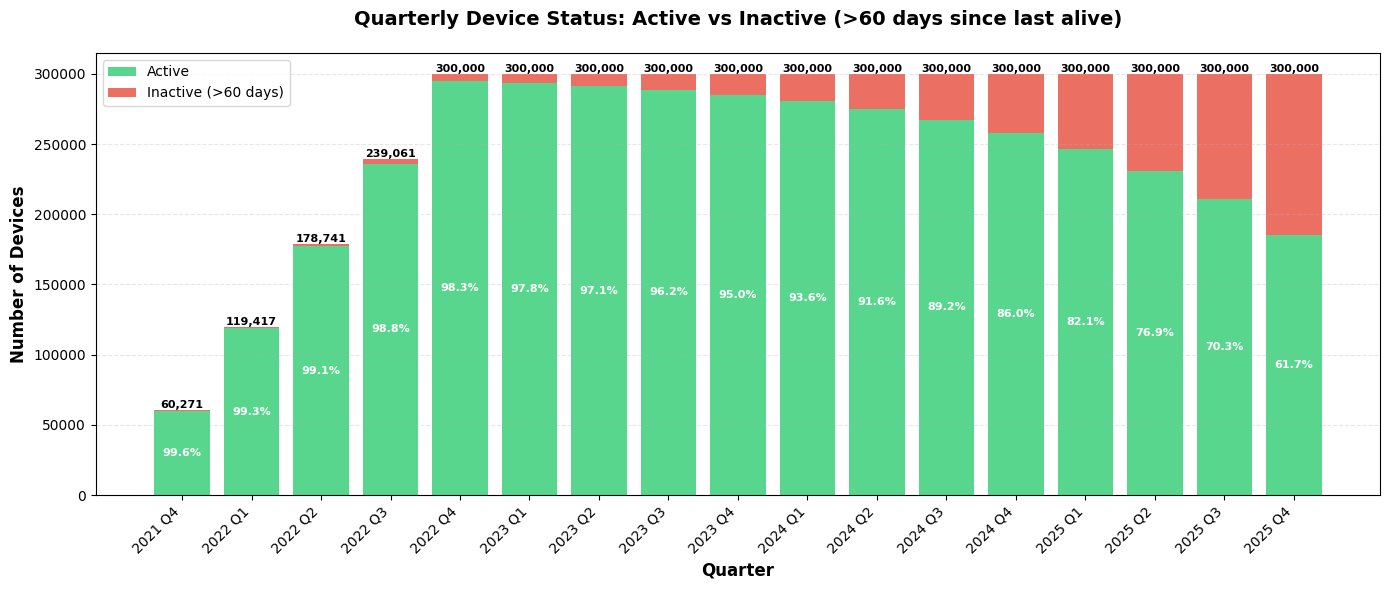


SUMMARY STATISTICS
Latest Quarter: 2025 Q4
  - Active Devices: 185,139
  - Inactive Devices: 114,861
  - Total Devices: 300,000
  - Active %: 61.71%


In [42]:
# Quarterly analysis of active vs inactive devices
# Logic: Device is active from ship_date until last_alive_date becomes >60 days old

# Prepare data
quarterly_data = merged_data.copy()
quarterly_data['ship_date'] = pd.to_datetime(quarterly_data['ship_date'], errors='coerce')
quarterly_data['last_alive_date'] = pd.to_datetime(quarterly_data['last_alive_date'], errors='coerce')

# Remove rows with missing dates
quarterly_data = quarterly_data.dropna(subset=['ship_date', 'last_alive_date'])

print(f"Total devices with valid dates: {len(quarterly_data)}")

# Calculate when each device became inactive (60 days after last_alive_date)
quarterly_data['inactive_date'] = quarterly_data['last_alive_date'] + pd.Timedelta(days=60)

# Create quarterly date range from earliest ship_date to today
min_date = quarterly_data['ship_date'].min()
max_date = pd.Timestamp.now()
quarters = pd.date_range(start=min_date.to_period('Q').to_timestamp(), 
                         end=max_date.to_period('Q').to_timestamp(), 
                         freq='QS')

print(f"\nAnalyzing {len(quarters)} quarters from {quarters[0].date()} to {quarters[-1].date()}")

# For each quarter, count active and inactive devices
results = []
for quarter_start in quarters:
    quarter_end = quarter_start + pd.offsets.QuarterEnd(0)
    
    # Devices are in this quarter if they were shipped by quarter_end
    shipped_by_quarter = quarterly_data[quarterly_data['ship_date'] <= quarter_end]
    
    # Active: devices where inactive_date is after quarter_end (still active at end of quarter)
    active_count = len(shipped_by_quarter[shipped_by_quarter['inactive_date'] > quarter_end])
    
    # Inactive: devices where inactive_date is before or at quarter_end
    inactive_count = len(shipped_by_quarter[shipped_by_quarter['inactive_date'] <= quarter_end])
    
    results.append({
        'Quarter': quarter_start,
        'Quarter_Label': f"{quarter_start.year} Q{quarter_start.quarter}",
        'Active': active_count,
        'Inactive': inactive_count,
        'Total': active_count + inactive_count
    })

quarterly_df = pd.DataFrame(results)
print("\nQuarterly Device Status Summary:")
display(quarterly_df)

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(14, 6))

x_pos = range(len(quarterly_df))
active_bars = ax.bar(x_pos, quarterly_df['Active'], label='Active', color='#2ecc71', alpha=0.8)
inactive_bars = ax.bar(x_pos, quarterly_df['Inactive'], 
                       bottom=quarterly_df['Active'], 
                       label='Inactive (>60 days)', 
                       color='#e74c3c', 
                       alpha=0.8)

# Customize chart
ax.set_xlabel('Quarter', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Devices', fontsize=12, fontweight='bold')
ax.set_title('Quarterly Device Status: Active vs Inactive (>60 days since last alive)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(quarterly_df['Quarter_Label'], rotation=45, ha='right')
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (active, inactive, total) in enumerate(zip(quarterly_df['Active'], 
                                                    quarterly_df['Inactive'], 
                                                    quarterly_df['Total'])):
    # Show total at top of stacked bar
    ax.text(i, total, f'{total:,}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    # Show percentage of active devices
    if total > 0:
        active_pct = (active / total) * 100
        if active > 0:
            ax.text(i, active/2, f'{active_pct:.1f}%', ha='center', va='center', 
                   fontsize=8, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Latest Quarter: {quarterly_df.iloc[-1]['Quarter_Label']}")
print(f"  - Active Devices: {quarterly_df.iloc[-1]['Active']:,}")
print(f"  - Inactive Devices: {quarterly_df.iloc[-1]['Inactive']:,}")
print(f"  - Total Devices: {quarterly_df.iloc[-1]['Total']:,}")
print(f"  - Active %: {(quarterly_df.iloc[-1]['Active']/quarterly_df.iloc[-1]['Total']*100):.2f}%")



8-QUARTER FORECAST: 2026 Q1 - 2027 Q4
First 3 quarters (2026 Q1-Q3) based on 2025 Q4 with progressive churn
Remaining quarters based on corresponding quarter from 4 years earlier

8-Quarter Forecast (2026 Q1 - 2027 Q4):
First 3 quarters: 2025 Q4 base with 1, 2, 3 quarters of 7% churn
Remaining quarters: 4-year earlier base with 16 quarters of 7% churn



,Forecast_Quarter,Base_Quarter,Quarters_Churn,Active,Inactive,Total,Active_Pct
0,2026 Q1,2025 Q4,1,172179.0,127821.0,300000,57.39
1,2026 Q2,2025 Q4,2,160127.0,139873.0,300000,53.38
2,2026 Q3,2025 Q4,3,148918.0,151082.0,300000,49.64
3,2026 Q4,2021 Q4,16,18789.0,41482.0,60271,31.17
4,2027 Q1,2022 Q1,16,37149.0,82268.0,119417,31.11
5,2027 Q2,2022 Q2,16,55463.0,123278.0,178741,31.03
6,2027 Q3,2022 Q3,16,73924.0,165137.0,239061,30.92
7,2027 Q4,2022 Q4,16,92368.0,207632.0,300000,30.79



✓ Chart data prepared: 25 quarters (17 historical + 8 forecast)
  Saved in 'chart_data' DataFrame


,Quarter_Label,Active,Inactive,Type
15,2025 Q3,210774.0,89226.0,Historical
16,2025 Q4,185139.0,114861.0,Historical
17,2026 Q1,172179.0,127821.0,Forecast
18,2026 Q2,160127.0,139873.0,Forecast
19,2026 Q3,148918.0,151082.0,Forecast
20,2026 Q4,18789.0,41482.0,Forecast
21,2027 Q1,37149.0,82268.0,Forecast
22,2027 Q2,55463.0,123278.0,Forecast
23,2027 Q3,73924.0,165137.0,Forecast
24,2027 Q4,92368.0,207632.0,Forecast


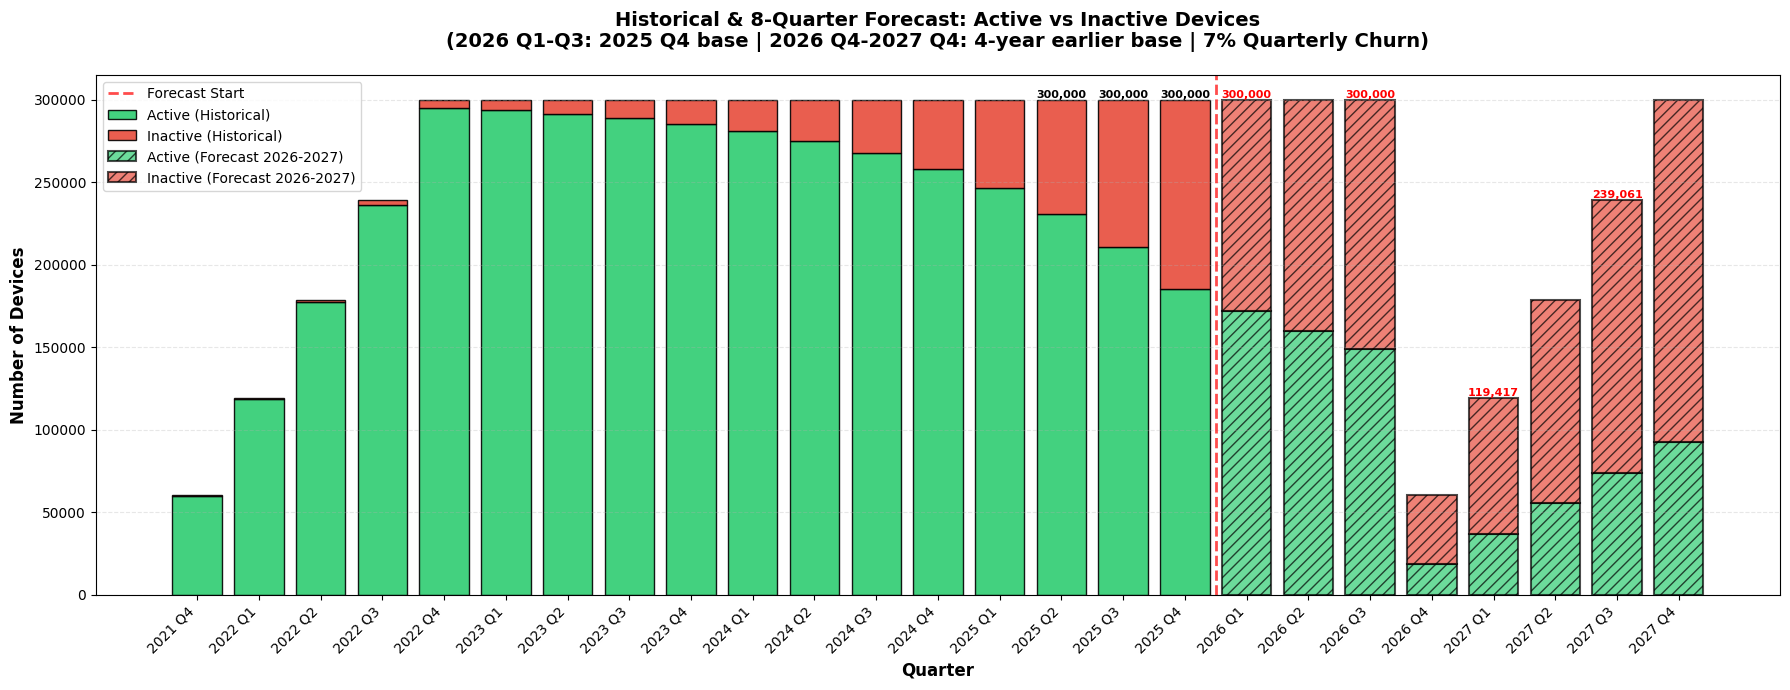


FORECAST SUMMARY

2025 Q4 → 2026 Q1 (1st Quarter - 1Q churn):
  Base Active: 185,139 | Forecast Active: 172,179
  Base Total: 300,000 | Forecast Total: 300,000
  Active %: 57.39%
  Retention after 1 quarter(s): 93.00%


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [64]:
# 8-quarter forecast: First 3 quarters based on 2025 Q4, rest based on 4 years earlier
import matplotlib.pyplot as plt

print("="*60)
print("8-QUARTER FORECAST: 2026 Q1 - 2027 Q4")
print("="*60)
print("First 3 quarters (2026 Q1-Q3) based on 2025 Q4 with progressive churn")
print("Remaining quarters based on corresponding quarter from 4 years earlier\n")

# Generate 8 quarters of forecasts
forecast_quarters = []

# Get 2025 Q4 data as base for first 3 quarters
q2025_q4 = quarterly_df[quarterly_df['Quarter_Label'] == '2025 Q4']
if len(q2025_q4) == 0:
    print("⚠️ Warning: 2025 Q4 not found in historical data")
    q2025_q4_active = None
    q2025_q4_total = None
else:
    q2025_q4_active = q2025_q4.iloc[0]['Active']
    q2025_q4_total = q2025_q4.iloc[0]['Total']

for i in range(8):
    # Forecast quarter
    forecast_year = 2026 + (i // 4)
    forecast_quarter = (i % 4) + 1
    forecast_label = f"{forecast_year} Q{forecast_quarter}"
    
    # First 3 quarters: Base on 2025 Q4
    if i < 3:
        if q2025_q4_active is None:
            print(f"⚠️ Skipping {forecast_label} - 2025 Q4 data not available")
            continue
            
        base_label = '2025 Q4'
        base_active = q2025_q4_active
        base_total = q2025_q4_total
        
        # Apply 7% quarterly churn for i+1 quarters (1, 2, or 3 quarters)
        quarters_forward = i + 1
        forecast_active = base_active * ((1 - 0.07) ** quarters_forward)
        forecast_total = base_total  # Total stays the same
        forecast_inactive = forecast_total - forecast_active
        
        forecast_quarters.append({
            'Forecast_Quarter': forecast_label,
            'Base_Quarter': base_label,
            'Active': round(forecast_active, 0),
            'Inactive': round(forecast_inactive, 0),
            'Total': round(forecast_total, 0),
            'Active_Pct': round((forecast_active / forecast_total) * 100, 2),
            'Base_Active': round(base_active, 0),
            'Base_Total': round(base_total, 0),
            'Quarters_Churn': quarters_forward
        })
    
    # Remaining quarters: 2026 Q4->2021 Q4, 2027 Q1->2022 Q1, etc.
    else:
        quarters_gap = 16  # 4 years = 16 quarters
        
        # Correct mapping: i=3->2021 Q4, i=4->2022 Q1, i=5->2022 Q2, etc.
        if i == 3:
            base_year = 2021
            base_quarter = 4
        else:
            base_year = 2022
            base_quarter = i - 3  # i=4->Q1, i=5->Q2, i=6->Q3, i=7->Q4
        
        base_label = f"{base_year} Q{base_quarter}"
        
        # Get base quarter data
        base_data = quarterly_df[quarterly_df['Quarter_Label'] == base_label]
        
        if len(base_data) > 0:
            base_active = base_data.iloc[0]['Active']
            base_inactive = base_data.iloc[0]['Inactive']
            base_total = base_active + base_inactive
            
            # Apply 7% quarterly churn compounded over 16 quarters (4 years)
            forecast_active = base_active * ((1 - 0.07) ** quarters_gap)
            forecast_total = base_total  # Total stays the same (matching base quarter size)
            forecast_inactive = forecast_total - forecast_active
            
            forecast_quarters.append({
                'Forecast_Quarter': forecast_label,
                'Base_Quarter': base_label,
                'Active': round(forecast_active, 0),
                'Inactive': round(forecast_inactive, 0),
                'Total': round(forecast_total, 0),
                'Active_Pct': round((forecast_active / forecast_total) * 100, 2),
                'Base_Active': round(base_active, 0),
                'Base_Total': round(base_total, 0),
                'Quarters_Churn': quarters_gap
            })
        else:
            print(f"⚠️ Warning: Base quarter {base_label} not found for forecast {forecast_label}")

forecast_df = pd.DataFrame(forecast_quarters)

print(f"8-Quarter Forecast (2026 Q1 - 2027 Q4):")
print(f"First 3 quarters: 2025 Q4 base with 1, 2, 3 quarters of 7% churn")
print(f"Remaining quarters: 4-year earlier base with 16 quarters of 7% churn\n")
display(forecast_df[['Forecast_Quarter', 'Base_Quarter', 'Quarters_Churn', 'Active', 'Inactive', 'Total', 'Active_Pct']])

# ==================== PREPARE CHART DATA ====================
# Combine historical and forecast data for visualization
chart_data = pd.concat([
    quarterly_df[['Quarter_Label', 'Active', 'Inactive']].copy(),
    forecast_df[['Forecast_Quarter', 'Active', 'Inactive']].rename(columns={'Forecast_Quarter': 'Quarter_Label'})
], ignore_index=True)

# Add a column to distinguish historical vs forecast
chart_data['Type'] = ['Historical'] * len(quarterly_df) + ['Forecast'] * len(forecast_df)

print(f"\n✓ Chart data prepared: {len(chart_data)} quarters ({len(quarterly_df)} historical + {len(forecast_df)} forecast)")
print(f"  Saved in 'chart_data' DataFrame")

display(chart_data.tail(10))

# ==================== STACKED BAR CHART ====================
fig, ax = plt.subplots(figsize=(18, 7))

# Prepare forecast data for chart
forecast_for_chart = forecast_df[['Forecast_Quarter', 'Active', 'Inactive']].rename(
    columns={'Forecast_Quarter': 'Quarter_Label'}
)

# Combine historical with 8-quarter forecast
all_quarters = pd.concat([
    quarterly_df[['Quarter_Label', 'Active', 'Inactive']],
    forecast_for_chart
], ignore_index=True)

x_pos = range(len(all_quarters))
active_vals = all_quarters['Active'].values
inactive_vals = all_quarters['Inactive'].values

# Historical bars (solid)
hist_len = len(quarterly_df)
ax.bar(x_pos[:hist_len], active_vals[:hist_len], label='Active (Historical)', 
       color='#2ecc71', alpha=0.9, edgecolor='black', linewidth=1)
ax.bar(x_pos[:hist_len], inactive_vals[:hist_len], bottom=active_vals[:hist_len],
       label='Inactive (Historical)', color='#e74c3c', alpha=0.9, edgecolor='black', linewidth=1)

# Forecast bars (hatched) - 8 quarters
ax.bar(x_pos[hist_len:], active_vals[hist_len:], label='Active (Forecast 2026-2027)', 
       color='#2ecc71', alpha=0.7, edgecolor='black', linewidth=1.5, hatch='///')
ax.bar(x_pos[hist_len:], inactive_vals[hist_len:], bottom=active_vals[hist_len:],
       label='Inactive (Forecast 2026-2027)', color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=1.5, hatch='///')

ax.axvline(hist_len - 0.5, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Forecast Start')

# Add value labels on bars (show every other for clarity)
for i, (active, inactive, total) in enumerate(zip(active_vals, inactive_vals, active_vals + inactive_vals)):
    if i >= hist_len:  # Forecast bars
        if (i - hist_len) % 2 == 0:  # Show every other forecast bar
            ax.text(i, total, f'{total:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold', color='red')
    elif i >= hist_len - 3:  # Last few historical bars
        ax.text(i, total, f'{total:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Quarter', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Devices', fontsize=12, fontweight='bold')
ax.set_title('Historical & 8-Quarter Forecast: Active vs Inactive Devices\n(2026 Q1-Q3: 2025 Q4 base | 2026 Q4-2027 Q4: 4-year earlier base | 7% Quarterly Churn)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(all_quarters['Quarter_Label'].values, rotation=45, ha='right')
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Change summary
print("\n" + "="*60)
print("FORECAST SUMMARY")
print("="*60)

if len(forecast_df) > 0:
    first_forecast = forecast_df.iloc[0]
    third_forecast = forecast_df.iloc[2] if len(forecast_df) > 2 else None
    fourth_forecast = forecast_df.iloc[3] if len(forecast_df) > 3 else None
    last_forecast = forecast_df.iloc[-1]
    
    print(f"\n{first_forecast['Base_Quarter']} → {first_forecast['Forecast_Quarter']} (1st Quarter - 1Q churn):")
    print(f"  Base Active: {first_forecast['Base_Active']:,.0f} | Forecast Active: {first_forecast['Active']:,.0f}")
    print(f"  Base Total: {first_forecast['Base_Total']:,.0f} | Forecast Total: {first_forecast['Total']:,.0f}")
    print(f"  Active %: {first_forecast['Active_Pct']:.2f}%")
    print(f"  Retention after {first_forecast['Quarters_Churn']} quarter(s): {((1 - 0.07) ** first_forecast['Quarters_Churn'] * 100):.2f}%")
    
    if third_forecast:
        print(f"\n{third_forecast['Base_Quarter']} → {third_forecast['Forecast_Quarter']} (3rd Quarter - 3Q churn):")
        print(f"  Base Active: {third_forecast['Base_Active']:,.0f} | Forecast Active: {third_forecast['Active']:,.0f}")
        print(f"  Active %: {third_forecast['Active_Pct']:.2f}%")
        print(f"  Retention after {third_forecast['Quarters_Churn']} quarters: {((1 - 0.07) ** third_forecast['Quarters_Churn'] * 100):.2f}%")
    
    if fourth_forecast:
        print(f"\n{fourth_forecast['Base_Quarter']} → {fourth_forecast['Forecast_Quarter']} (4th Quarter - switching to 4-year base):")
        print(f"  Base Active: {fourth_forecast['Base_Active']:,.0f} | Forecast Active: {fourth_forecast['Active']:,.0f}")
        print(f"  Base Total: {fourth_forecast['Base_Total']:,.0f} | Forecast Total: {fourth_forecast['Total']:,.0f}")
        print(f"  Active %: {fourth_forecast['Active_Pct']:.2f}%")
        print(f"  Retention after {fourth_forecast['Quarters_Churn']} quarters: {((1 - 0.07) ** fourth_forecast['Quarters_Churn'] * 100):.2f}%")
    
    print(f"\n{last_forecast['Base_Quarter']} → {last_forecast['Forecast_Quarter']} (Last Forecast):")
    print(f"  Base Active: {last_forecast['Base_Active']:,.0f} | Forecast Active: {last_forecast['Active']:,.0f}")
    print(f"  Base Total: {last_forecast['Base_Total']:,.0f} | Forecast Total: {last_forecast['Total']:,.0f}")
    print(f"  Active %: {last_forecast['Active_Pct']:.2f}%")
    print(f"  Retention after {last_forecast['Quarters_Churn']} quarters: {((1 - 0.07) ** last_forecast['Quarters_Churn'] * 100):.2f}%")
else:
    print("\n⚠️ No forecast data generated.")

In [72]:
# ==================== GENERATE COMPREHENSIVE VISUALIZATION DATAFRAME ====================
# Create a clean, complete DataFrame for easy stacked bar chart visualization

# Combine historical and forecast data
viz_data = pd.concat([
    # Historical data
    quarterly_df[['Quarter_Label', 'Active', 'Inactive']].assign(
        Type='Historical',
        Quarter=quarterly_df['Quarter_Label'].str.extract(r'Q(\d)')[0].astype(int),
        Year=quarterly_df['Quarter_Label'].str.extract(r'(\d{4})')[0].astype(int)
    ),
    # Forecast data
    forecast_df[['Forecast_Quarter', 'Active', 'Inactive']].rename(
        columns={'Forecast_Quarter': 'Quarter_Label'}
    ).assign(
        Type='Forecast',
        Quarter=forecast_df['Forecast_Quarter'].str.extract(r'Q(\d)')[0].astype(int),
        Year=forecast_df['Forecast_Quarter'].str.extract(r'(\d{4})')[0].astype(int)
    )
], ignore_index=True)

# Calculate additional useful columns
viz_data['Total'] = viz_data['Active'] + viz_data['Inactive']
viz_data['Active_Pct'] = (viz_data['Active'] / viz_data['Total'] * 100).round(2)
viz_data['Inactive_Pct'] = (viz_data['Inactive'] / viz_data['Total'] * 100).round(2)

# Add period identifier (useful for splitting historical/forecast)
viz_data['Period'] = range(len(viz_data))
viz_data['Is_Forecast'] = viz_data['Type'] == 'Forecast'

# Reorder columns for clarity
viz_data = viz_data[[
    'Period', 'Quarter_Label', 'Year', 'Quarter', 'Type', 'Is_Forecast',
    'Active', 'Inactive', 'Total', 'Active_Pct', 'Inactive_Pct'
]]

print("="*80)
print("COMPREHENSIVE VISUALIZATION DATAFRAME")
print("="*80)
print(f"\nTotal periods: {len(viz_data)}")
print(f"Historical periods: {(viz_data['Type'] == 'Historical').sum()}")
print(f"Forecast periods: {(viz_data['Type'] == 'Forecast').sum()}")
print(f"\nDaterange: {viz_data['Quarter_Label'].iloc[0]} to {viz_data['Quarter_Label'].iloc[-1]}")

print("\n--- Sample: Last 5 Historical Periods ---")
display(viz_data[viz_data['Type'] == 'Historical'].tail(5))

print("\n--- Sample: All Forecast Periods ---")
display(viz_data[viz_data['Type'] == 'Forecast'])

print("\n✓ DataFrame saved as 'viz_data' - Ready for stacked bar charts!")
print("\nUseful columns:")
print("  • Period: Sequential number (0 to n)")
print("  • Quarter_Label: '2024 Q1' format")
print("  • Type: 'Historical' or 'Forecast'")
print("  • Active/Inactive: Device counts")
print("  • Active_Pct/Inactive_Pct: Percentages")
print("  • Is_Forecast: Boolean for easy filtering")


COMPREHENSIVE VISUALIZATION DATAFRAME

Total periods: 25
Historical periods: 17
Forecast periods: 8

Daterange: 2021 Q4 to 2027 Q4

--- Sample: Last 5 Historical Periods ---


,Period,Quarter_Label,Year,Quarter,Type,Is_Forecast,Active,Inactive,Total,Active_Pct,Inactive_Pct
12,12,2024 Q4,2024,4,Historical,False,257976.0,42024.0,300000.0,85.99,14.01
13,13,2025 Q1,2025,1,Historical,False,246196.0,53804.0,300000.0,82.07,17.93
14,14,2025 Q2,2025,2,Historical,False,230842.0,69158.0,300000.0,76.95,23.05
15,15,2025 Q3,2025,3,Historical,False,210774.0,89226.0,300000.0,70.26,29.74
16,16,2025 Q4,2025,4,Historical,False,185139.0,114861.0,300000.0,61.71,38.29



--- Sample: All Forecast Periods ---


,Period,Quarter_Label,Year,Quarter,Type,Is_Forecast,Active,Inactive,Total,Active_Pct,Inactive_Pct
17,17,2026 Q1,2026,1,Forecast,True,172179.0,127821.0,300000.0,57.39,42.61
18,18,2026 Q2,2026,2,Forecast,True,160127.0,139873.0,300000.0,53.38,46.62
19,19,2026 Q3,2026,3,Forecast,True,148918.0,151082.0,300000.0,49.64,50.36
20,20,2026 Q4,2026,4,Forecast,True,18789.0,41482.0,60271.0,31.17,68.83
21,21,2027 Q1,2027,1,Forecast,True,37149.0,82268.0,119417.0,31.11,68.89
22,22,2027 Q2,2027,2,Forecast,True,55463.0,123278.0,178741.0,31.03,68.97
23,23,2027 Q3,2027,3,Forecast,True,73924.0,165137.0,239061.0,30.92,69.08
24,24,2027 Q4,2027,4,Forecast,True,92368.0,207632.0,300000.0,30.79,69.21



✓ DataFrame saved as 'viz_data' - Ready for stacked bar charts!

Useful columns:
  • Period: Sequential number (0 to n)
  • Quarter_Label: '2024 Q1' format
  • Type: 'Historical' or 'Forecast'
  • Active/Inactive: Device counts
  • Active_Pct/Inactive_Pct: Percentages
  • Is_Forecast: Boolean for easy filtering


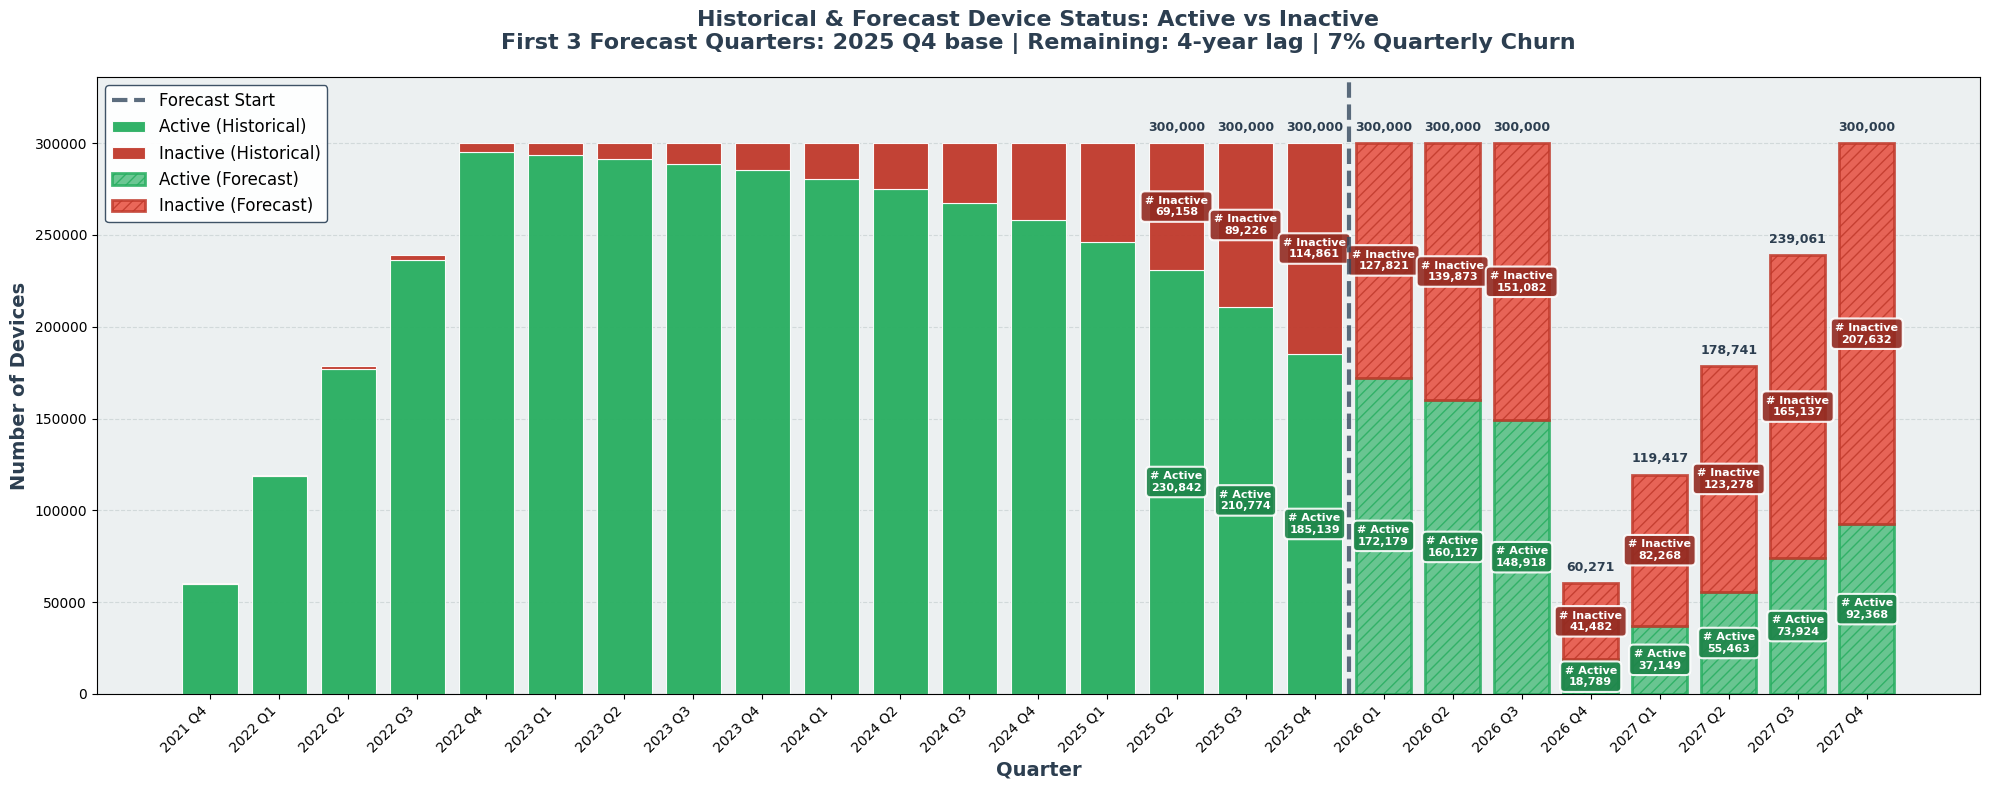


VISUALIZATION SUMMARY

📊 Data Coverage:
  • Total quarters displayed: 25
  • Historical: 17 quarters (2021 Q4 to 2025 Q4)
  • Forecast: 8 quarters (2026 Q1 to 2027 Q4)

📈 Latest Historical (Current State):
  • Quarter: 2025 Q4
  • Active: 185,139 (61.7%)
  • Inactive: 114,861 (38.3%)
  • Total: 300,000

🔮 Final Forecast:
  • Quarter: 2027 Q4
  • Active: 92,368 (30.8%)
  • Inactive: 207,632 (69.2%)
  • Total: 300,000

📉 Change from Current to Final Forecast:
  • Active change: -92,771 (-50.1%)
  • Inactive change: 92,771 (80.8%)
  • Active % change: -30.9 percentage points


In [73]:
# ==================== EASY STACKED BAR CHART USING VIZ_DATA ====================
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20, 8))

# Split data by type for different styling
historical = viz_data[viz_data['Type'] == 'Historical']
forecast = viz_data[viz_data['Type'] == 'Forecast']

# Historical bars (solid)
hist_periods = historical['Period'].values
ax.bar(hist_periods, historical['Active'], 
       label='Active (Historical)', 
       color='#27ae60', alpha=0.95, edgecolor='white', linewidth=0.8)
ax.bar(hist_periods, historical['Inactive'], 
       bottom=historical['Active'],
       label='Inactive (Historical)', 
       color='#c0392b', alpha=0.95, edgecolor='white', linewidth=0.8)

# Forecast bars (hatched)
forecast_periods = forecast['Period'].values
ax.bar(forecast_periods, forecast['Active'], 
       label='Active (Forecast)', 
       color='#52be80', alpha=0.85, edgecolor='#27ae60', linewidth=2, hatch='///')
ax.bar(forecast_periods, forecast['Inactive'], 
       bottom=forecast['Active'],
       label='Inactive (Forecast)', 
       color='#e74c3c', alpha=0.85, edgecolor='#c0392b', linewidth=2, hatch='///')

# Add vertical line between historical and forecast
if len(forecast) > 0:
    split_point = forecast['Period'].iloc[0] - 0.5
    ax.axvline(split_point, color='#34495e', linestyle='--', linewidth=3, 
               alpha=0.8, label='Forecast Start', zorder=10)

# Add labels to bars (show last 3 historical + all forecast)
label_indices = list(historical.tail(3).index) + list(forecast.index)
for idx in label_indices:
    row = viz_data.loc[idx]
    period = row['Period']
    total = row['Total']
    active = row['Active']
    inactive = row['Inactive']
    
    # Total at top
    ax.text(period, total + 5000, f"{total:,.0f}", 
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='#2c3e50')
    
    # Active label
    if active > 0:
        ax.text(period, active/2, f"# Active\n{active:,.0f}", 
                ha='center', va='center', fontsize=8, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#1e8449', 
                         alpha=0.9, edgecolor='white', linewidth=1.5))
    
    # Inactive label
    if inactive > 0:
        ax.text(period, active + inactive/2, f"# Inactive\n{inactive:,.0f}", 
                ha='center', va='center', fontsize=8, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#922b21', 
                         alpha=0.9, edgecolor='white', linewidth=1.5))

# Styling
ax.set_xlabel('Quarter', fontsize=14, fontweight='bold', color='#2c3e50')
ax.set_ylabel('Number of Devices', fontsize=14, fontweight='bold', color='#2c3e50')
ax.set_title('Historical & Forecast Device Status: Active vs Inactive\n' +
             'First 3 Forecast Quarters: 2025 Q4 base | Remaining: 4-year lag | 7% Quarterly Churn',
             fontsize=16, fontweight='bold', color='#2c3e50', pad=20)

# X-axis labels
ax.set_xticks(viz_data['Period'].values)
ax.set_xticklabels(viz_data['Quarter_Label'].values, rotation=45, ha='right', fontsize=10)
ax.set_ylim(0, viz_data['Total'].max() * 1.12)

# Legend
ax.legend(loc='upper left', fontsize=12, framealpha=0.95, edgecolor='#34495e', fancybox=True)

# Grid
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8, color='#95a5a6')
ax.set_axisbelow(True)

# Background
ax.set_facecolor('#ecf0f1')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()

# Summary stats
print("\n" + "="*80)
print("VISUALIZATION SUMMARY")
print("="*80)
print(f"\n📊 Data Coverage:")
print(f"  • Total quarters displayed: {len(viz_data)}")
print(f"  • Historical: {len(historical)} quarters ({historical['Quarter_Label'].iloc[0]} to {historical['Quarter_Label'].iloc[-1]})")
print(f"  • Forecast: {len(forecast)} quarters ({forecast['Quarter_Label'].iloc[0]} to {forecast['Quarter_Label'].iloc[-1]})")

print(f"\n📈 Latest Historical (Current State):")
latest_hist = historical.iloc[-1]
print(f"  • Quarter: {latest_hist['Quarter_Label']}")
print(f"  • Active: {latest_hist['Active']:,.0f} ({latest_hist['Active_Pct']:.1f}%)")
print(f"  • Inactive: {latest_hist['Inactive']:,.0f} ({latest_hist['Inactive_Pct']:.1f}%)")
print(f"  • Total: {latest_hist['Total']:,.0f}")

print(f"\n🔮 Final Forecast:")
last_forecast = forecast.iloc[-1]
print(f"  • Quarter: {last_forecast['Quarter_Label']}")
print(f"  • Active: {last_forecast['Active']:,.0f} ({last_forecast['Active_Pct']:.1f}%)")
print(f"  • Inactive: {last_forecast['Inactive']:,.0f} ({last_forecast['Inactive_Pct']:.1f}%)")
print(f"  • Total: {last_forecast['Total']:,.0f}")

print(f"\n📉 Change from Current to Final Forecast:")
print(f"  • Active change: {last_forecast['Active'] - latest_hist['Active']:,.0f} ({((last_forecast['Active'] / latest_hist['Active'] - 1) * 100):.1f}%)")
print(f"  • Inactive change: {last_forecast['Inactive'] - latest_hist['Inactive']:,.0f} ({((last_forecast['Inactive'] / latest_hist['Inactive'] - 1) * 100):.1f}%)")
print(f"  • Active % change: {last_forecast['Active_Pct'] - latest_hist['Active_Pct']:.1f} percentage points")


In [74]:
# ==================== QUICK REFERENCE: USEFUL VIZ_DATA QUERIES ====================
print("="*80)
print("QUICK REFERENCE: USEFUL VIZ_DATA QUERIES")
print("="*80)

print("\n1️⃣ Filter by Type:")
print("   viz_data[viz_data['Type'] == 'Historical']")
print("   viz_data[viz_data['Type'] == 'Forecast']")
print("   viz_data[viz_data['Is_Forecast'] == True]")

print("\n2️⃣ Filter by Year:")
print("   viz_data[viz_data['Year'] == 2024]")
print("   viz_data[viz_data['Year'] >= 2023]")

print("\n3️⃣ Filter by Quarter:")
print("   viz_data[viz_data['Quarter'] == 4]  # All Q4s")
print("   viz_data[viz_data['Quarter_Label'] == '2025 Q4']  # Specific quarter")

print("\n4️⃣ Get Specific Periods:")
print("   viz_data.head(10)  # First 10 quarters")
print("   viz_data.tail(5)   # Last 5 quarters")
print("   viz_data.iloc[10:20]  # Quarters 10-20")

print("\n5️⃣ Get Transition Point:")
print("   last_historical = viz_data[viz_data['Type'] == 'Historical'].iloc[-1]")
print("   first_forecast = viz_data[viz_data['Type'] == 'Forecast'].iloc[0]")

print("\n6️⃣ Calculate Aggregates:")
print("   viz_data.groupby('Type')[['Active', 'Inactive']].sum()")
print("   viz_data.groupby('Year')['Active_Pct'].mean()")

print("\n7️⃣ Export for External Tools:")
print("   viz_data.to_csv('device_forecast.csv', index=False)")
print("   viz_data.to_excel('device_forecast.xlsx', index=False)")

# Example: Show year-over-year comparison
print("\n" + "="*80)
print("EXAMPLE: Year-over-Year Q4 Comparison")
print("="*80)
q4_data = viz_data[viz_data['Quarter'] == 4][['Quarter_Label', 'Active', 'Inactive', 'Active_Pct', 'Type']]
display(q4_data)

# Example: Show forecast progression
print("\n" + "="*80)
print("EXAMPLE: Forecast Progression (Active Device Decline)")
print("="*80)
forecast_progression = viz_data[viz_data['Type'] == 'Forecast'][['Quarter_Label', 'Active', 'Inactive', 'Active_Pct']]
forecast_progression['Active_Change'] = forecast_progression['Active'].diff()
forecast_progression['Active_Pct_Change'] = forecast_progression['Active_Pct'].diff()
display(forecast_progression)

print("\n✓ viz_data DataFrame is ready for any custom visualization or export!")


QUICK REFERENCE: USEFUL VIZ_DATA QUERIES

1️⃣ Filter by Type:
   viz_data[viz_data['Type'] == 'Historical']
   viz_data[viz_data['Type'] == 'Forecast']
   viz_data[viz_data['Is_Forecast'] == True]

2️⃣ Filter by Year:
   viz_data[viz_data['Year'] == 2024]
   viz_data[viz_data['Year'] >= 2023]

3️⃣ Filter by Quarter:
   viz_data[viz_data['Quarter'] == 4]  # All Q4s
   viz_data[viz_data['Quarter_Label'] == '2025 Q4']  # Specific quarter

4️⃣ Get Specific Periods:
   viz_data.head(10)  # First 10 quarters
   viz_data.tail(5)   # Last 5 quarters
   viz_data.iloc[10:20]  # Quarters 10-20

5️⃣ Get Transition Point:
   last_historical = viz_data[viz_data['Type'] == 'Historical'].iloc[-1]
   first_forecast = viz_data[viz_data['Type'] == 'Forecast'].iloc[0]

6️⃣ Calculate Aggregates:
   viz_data.groupby('Type')[['Active', 'Inactive']].sum()
   viz_data.groupby('Year')['Active_Pct'].mean()

7️⃣ Export for External Tools:
   viz_data.to_csv('device_forecast.csv', index=False)
   viz_data.to_excel

,Quarter_Label,Active,Inactive,Active_Pct,Type
0,2021 Q4,60003.0,268.0,99.56,Historical
4,2022 Q4,294980.0,5020.0,98.33,Historical
8,2023 Q4,285100.0,14900.0,95.03,Historical
12,2024 Q4,257976.0,42024.0,85.99,Historical
16,2025 Q4,185139.0,114861.0,61.71,Historical
20,2026 Q4,18789.0,41482.0,31.17,Forecast
24,2027 Q4,92368.0,207632.0,30.79,Forecast



EXAMPLE: Forecast Progression (Active Device Decline)


,Quarter_Label,Active,Inactive,Active_Pct,Active_Change,Active_Pct_Change
17,2026 Q1,172179.0,127821.0,57.39,NaN,NaN
18,2026 Q2,160127.0,139873.0,53.38,-12052.0,-4.01
19,2026 Q3,148918.0,151082.0,49.64,-11209.0,-3.74
20,2026 Q4,18789.0,41482.0,31.17,-130129.0,-18.47
21,2027 Q1,37149.0,82268.0,31.11,18360.0,-0.06
22,2027 Q2,55463.0,123278.0,31.03,18314.0,-0.08
23,2027 Q3,73924.0,165137.0,30.92,18461.0,-0.11
24,2027 Q4,92368.0,207632.0,30.79,18444.0,-0.13



✓ viz_data DataFrame is ready for any custom visualization or export!


WHEN DEVICES BECAME INACTIVE - YEARLY ANALYSIS
Total devices analyzed: 300,000

Analyzing devices that became inactive from 2021 to 2025

Devices That Became Inactive Each Year:


,Inactive_Year,Devices_Became_Inactive
0,2021,1347
1,2022,3673
2,2023,9880
3,2024,27124
4,2025,60025



DETAILED: Which Ship Years Went Inactive Each Year


inactive_year,2021,2022,2023,2024,2025,Total
ship_year,,,,,,
2021,268,733,1952,5494,12103,20550
2022,1079,2940,7928,21630,47922,81499
Total,1347,3673,9880,27124,60025,102049


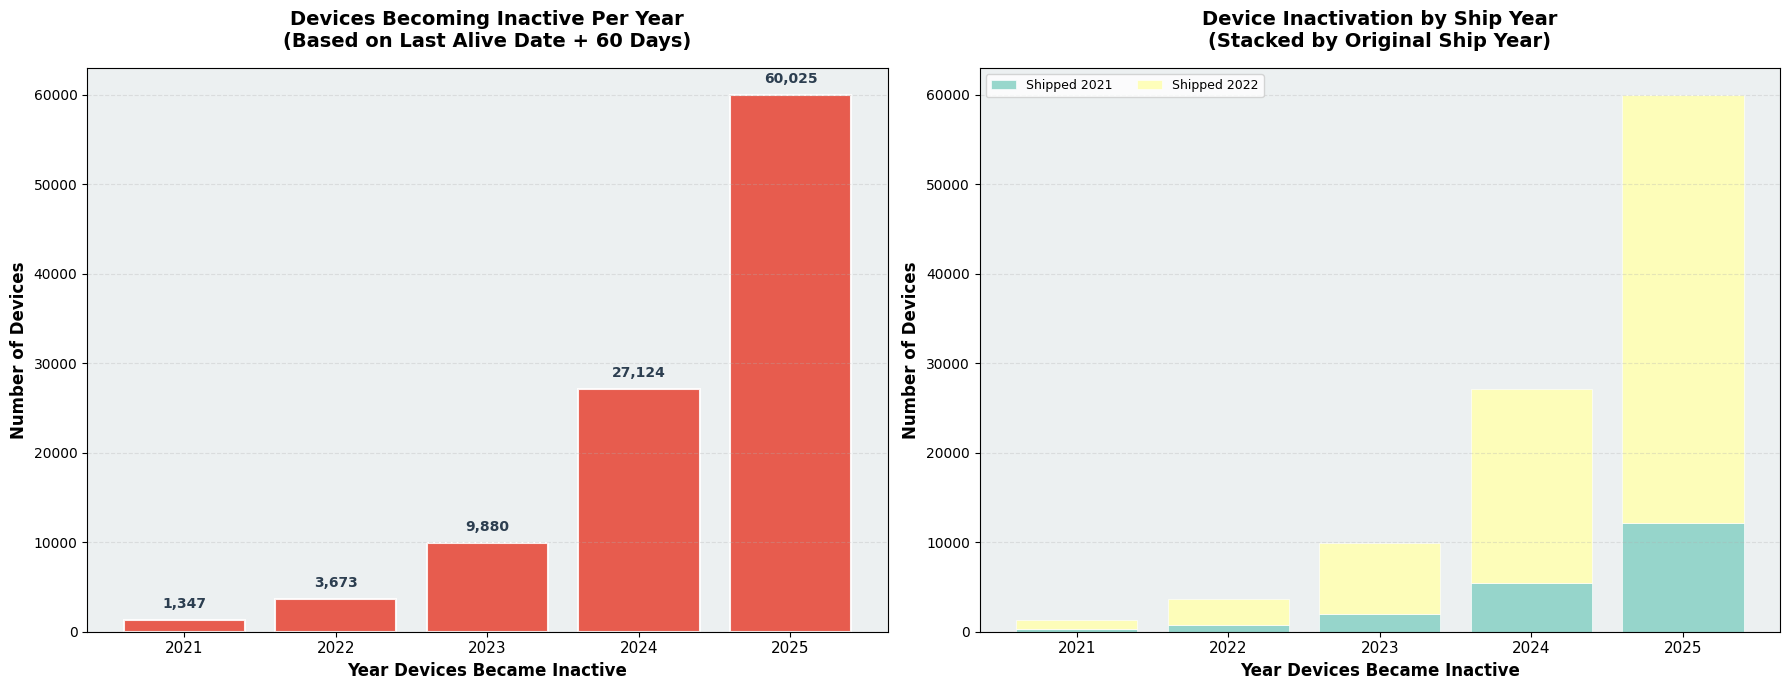


KEY INSIGHTS

📊 OVERALL:
  • Total devices that have become inactive: 102,049
  • Currently still active: 197,951

📈 PEAK INACTIVATION:
  • Year: 2025
  • Devices: 60,025

📉 RECENT TREND (Last 3 Years):
  • 2023: 9,880 devices went inactive
  • 2024: 27,124 devices went inactive
  • 2025: 60,025 devices went inactive

✅ STILL ACTIVE:
  • 197,951 devices (65.98%)


In [ ]:
# ==================== WHEN DEVICES BECAME INACTIVE BY YEAR ====================
# Track when devices went inactive based on ship_date and last_alive_date
# For each device: inactive_date = last_alive_date + 60 days

import matplotlib.pyplot as plt

# Prepare data
inactive_timeline = merged_data.copy()
inactive_timeline['ship_date'] = pd.to_datetime(inactive_timeline['ship_date'], errors='coerce')
inactive_timeline['last_alive_date'] = pd.to_datetime(inactive_timeline['last_alive_date'], errors='coerce')

# Remove rows with missing dates
inactive_timeline = inactive_timeline.dropna(subset=['ship_date', 'last_alive_date'])

print("="*80)
print("WHEN DEVICES BECAME INACTIVE - YEARLY ANALYSIS")
print("="*80)
print(f"Total devices analyzed: {len(inactive_timeline):,}\n")

# Calculate when each device became inactive (60 days after last_alive_date)
inactive_timeline['inactive_date'] = inactive_timeline['last_alive_date'] + pd.Timedelta(days=60)
today = pd.Timestamp.now()

# Extract years
inactive_timeline['ship_year'] = inactive_timeline['ship_date'].dt.year
inactive_timeline['inactive_year'] = inactive_timeline['inactive_date'].dt.year

# Mark if device is currently inactive (inactive_date has passed)
inactive_timeline['is_currently_inactive'] = inactive_timeline['inactive_date'] <= today

# For each year, count how many devices became inactive in that year
results_by_inactive_year = []
inactive_years = sorted(inactive_timeline[inactive_timeline['is_currently_inactive']]['inactive_year'].unique())

print(f"Analyzing devices that became inactive from {inactive_years[0]} to {inactive_years[-1]}\n")

for year in inactive_years:
    # Devices that became inactive in this year
    devices_inactive_this_year = inactive_timeline[
        (inactive_timeline['inactive_year'] == year) & 
        (inactive_timeline['is_currently_inactive'])
    ]
    
    count = len(devices_inactive_this_year)
    
    # Get ship year distribution
    ship_year_dist = devices_inactive_this_year['ship_year'].value_counts().to_dict()
    
    results_by_inactive_year.append({
        'Inactive_Year': year,
        'Devices_Became_Inactive': count,
        'Ship_Year_Distribution': ship_year_dist
    })

inactive_by_year_df = pd.DataFrame(results_by_inactive_year)

print("Devices That Became Inactive Each Year:")
display(inactive_by_year_df[['Inactive_Year', 'Devices_Became_Inactive']])

# ==================== DETAILED BREAKDOWN ====================
print("\n" + "="*80)
print("DETAILED: Which Ship Years Went Inactive Each Year")
print("="*80)

# Create a cross-tabulation: ship_year x inactive_year
crosstab_data = inactive_timeline[inactive_timeline['is_currently_inactive']].copy()
ship_inactive_crosstab = pd.crosstab(
    crosstab_data['ship_year'], 
    crosstab_data['inactive_year'],
    margins=True,
    margins_name='Total'
)

display(ship_inactive_crosstab)

# ==================== VISUALIZATION ====================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Chart 1: Bar chart of devices becoming inactive each year
ax1 = axes[0]
years = inactive_by_year_df['Inactive_Year'].astype(str)
counts = inactive_by_year_df['Devices_Became_Inactive']
x_pos = range(len(years))

bars = ax1.bar(x_pos, counts, color='#e74c3c', alpha=0.9, edgecolor='white', linewidth=1.5)

# Add value labels
for i, count in enumerate(counts):
    ax1.text(i, count + 1000, f'{count:,}', ha='center', va='bottom', 
             fontsize=10, fontweight='bold', color='#2c3e50')

ax1.set_xlabel('Year Devices Became Inactive', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Devices', fontsize=12, fontweight='bold')
ax1.set_title('Devices Becoming Inactive Per Year\n(Based on Last Alive Date + 60 Days)', 
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(years, fontsize=11)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_facecolor('#ecf0f1')

# Chart 2: Stacked bar showing ship year composition
ax2 = axes[1]

# Prepare stacked data
ship_years_all = sorted(inactive_timeline['ship_year'].unique())
inactive_years_all = sorted([y for y in inactive_timeline['inactive_year'].unique() if y <= today.year])

# Create matrix for stacking
stack_data = {}
for ship_year in ship_years_all:
    stack_data[f'{ship_year}'] = []
    for inactive_year in inactive_years_all:
        count = len(inactive_timeline[
            (inactive_timeline['ship_year'] == ship_year) &
            (inactive_timeline['inactive_year'] == inactive_year) &
            (inactive_timeline['is_currently_inactive'])
        ])
        stack_data[f'{ship_year}'].append(count)

# Plot stacked bars
x_pos2 = range(len(inactive_years_all))
bottom = [0] * len(inactive_years_all)
colors = plt.cm.Set3(range(len(ship_years_all)))

for idx, ship_year in enumerate(ship_years_all):
    values = stack_data[f'{ship_year}']
    ax2.bar(x_pos2, values, bottom=bottom, label=f'Shipped {ship_year}', 
            color=colors[idx], alpha=0.9, edgecolor='white', linewidth=0.5)
    bottom = [b + v for b, v in zip(bottom, values)]

ax2.set_xlabel('Year Devices Became Inactive', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Devices', fontsize=12, fontweight='bold')
ax2.set_title('Device Inactivation by Ship Year\n(Stacked by Original Ship Year)', 
              fontsize=14, fontweight='bold', pad=15)
ax2.set_xticks(x_pos2)
ax2.set_xticklabels([str(y) for y in inactive_years_all], fontsize=11)
ax2.legend(loc='upper left', fontsize=9, ncol=2)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_facecolor('#ecf0f1')

plt.tight_layout()
plt.show()

# ==================== SUMMARY INSIGHTS ====================
print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)

total_inactive = inactive_by_year_df['Devices_Became_Inactive'].sum()
peak_year = inactive_by_year_df.loc[inactive_by_year_df['Devices_Became_Inactive'].idxmax()]

print(f"\n📊 OVERALL:")
print(f"  • Total devices that have become inactive: {total_inactive:,}")
print(f"  • Currently still active: {(inactive_timeline['is_currently_inactive'] == False).sum():,}")

print(f"\n📈 PEAK INACTIVATION:")
print(f"  • Year: {peak_year['Inactive_Year']}")
print(f"  • Devices: {peak_year['Devices_Became_Inactive']:,}")

# Recent trend
if len(inactive_by_year_df) >= 3:
    recent_years = inactive_by_year_df.tail(3)
    print(f"\n📉 RECENT TREND (Last 3 Years):")
    for _, row in recent_years.iterrows():
        print(f"  • {row['Inactive_Year']}: {row['Devices_Became_Inactive']:,} devices went inactive")

# Still active devices
still_active = len(inactive_timeline[inactive_timeline['is_currently_inactive'] == False])
print(f"\n✅ STILL ACTIVE:")
print(f"  • {still_active:,} devices ({still_active/len(inactive_timeline)*100:.2f}%)")

In [76]:
viz_data.to_csv('viz_data.csv', index=False)

In [77]:
viz_data

,Period,Quarter_Label,Year,Quarter,Type,Is_Forecast,Active,Inactive,Total,Active_Pct,Inactive_Pct
0,0,2021 Q4,2021,4,Historical,False,60003.0,268.0,60271.0,99.56,0.44
1,1,2022 Q1,2022,1,Historical,False,118638.0,779.0,119417.0,99.35,0.65
2,2,2022 Q2,2022,2,Historical,False,177124.0,1617.0,178741.0,99.10,0.90
3,3,2022 Q3,2022,3,Historical,False,236079.0,2982.0,239061.0,98.75,1.25
4,4,2022 Q4,2022,4,Historical,False,294980.0,5020.0,300000.0,98.33,1.67
5,5,2023 Q1,2023,1,Historical,False,293371.0,6629.0,300000.0,97.79,2.21
6,6,2023 Q2,2023,2,Historical,False,291284.0,8716.0,300000.0,97.09,2.91
7,7,2023 Q3,2023,3,Historical,False,288634.0,11366.0,300000.0,96.21,3.79
8,8,2023 Q4,2023,4,Historical,False,285100.0,14900.0,300000.0,95.03,4.97
9,9,2024 Q1,2024,1,Historical,False,280654.0,19346.0,300000.0,93.55,6.45


In [80]:
inactive_by_year_df.to_csv('inactive_by_year_df.csv', index=False)


In [81]:
inactive_by_year_df

,Inactive_Year,Devices_Became_Inactive,Ship_Year_Distribution
0,2021,1347,"{2022: 1079, 2021: 268}"
1,2022,3673,"{2022: 2940, 2021: 733}"
2,2023,9880,"{2022: 7928, 2021: 1952}"
3,2024,27124,"{2022: 21630, 2021: 5494}"
4,2025,60025,"{2022: 47922, 2021: 12103}"


DEVICE LIFESPAN ANALYSIS: COUNTS & PERCENTAGES

📊 BASE DENOMINATORS:
  • Total devices in dataset: 300,000
  • Devices that have become inactive: 102,049 (Base for % calculations)
  • Devices still active: 197,951
  • Inactive rate: 34.02%

DEVICES BY LIFESPAN (Years Active Before Becoming Inactive)

Base Denominator for Pct_of_Inactive: 102,049 inactive devices
Base Denominator for Pct_of_Total: 300,000 total devices



,Lifespan,Count,Pct_of_Inactive,Pct_of_Total
0,Less than 1 year,8150,7.99,2.72
1,1 year,15555,15.24,5.18
2,2 years,40900,40.08,13.63
3,3 years,36713,35.98,12.24
4,4 years,731,0.72,0.24
5,5 years,0,0.00,0.00
6,6 years,0,0.00,0.00
7,6+ years,0,0.00,0.00



VALIDATION
Sum of counts: 102,049 (should equal 102,049)
Sum of Pct_of_Inactive: 100.01% (should equal ~100%)


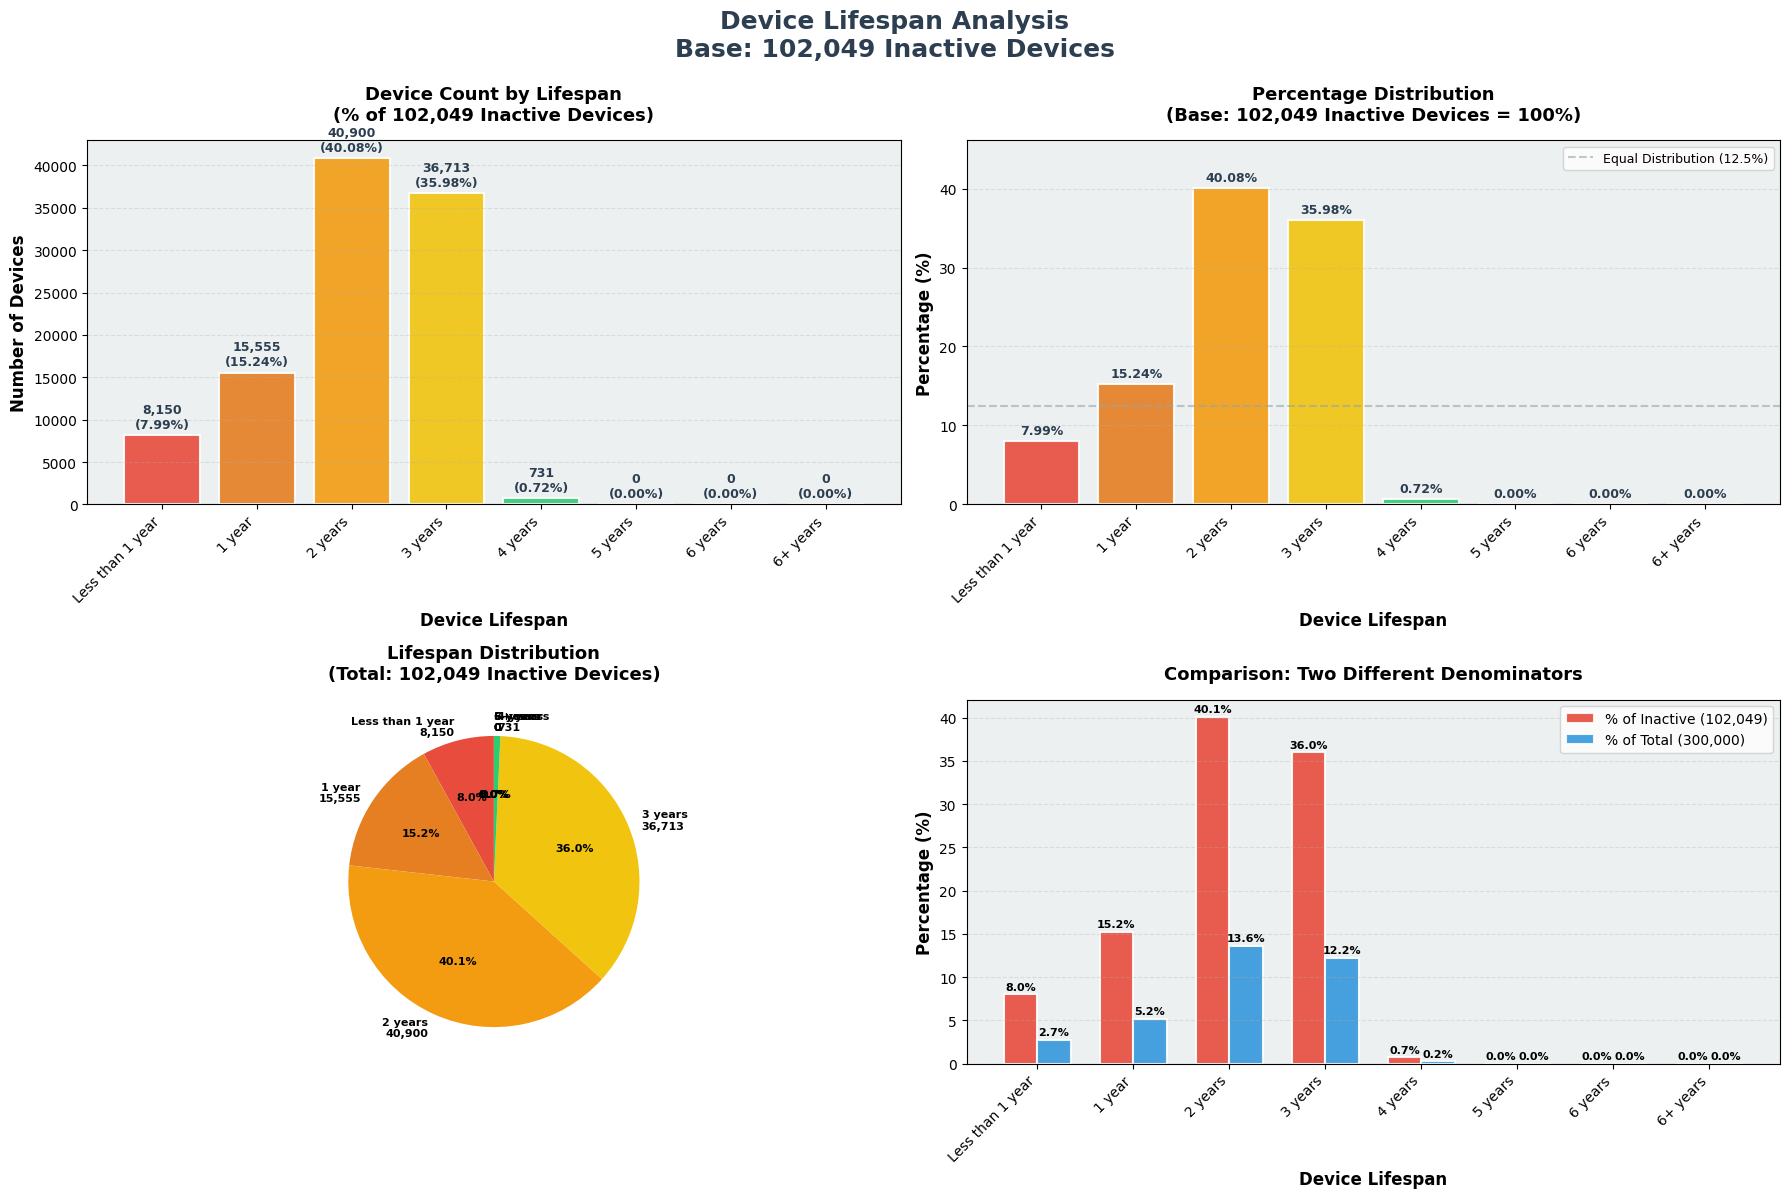


DETAILED STATISTICS (Inactive Devices Only)

Average lifespan: 2.06 years
Median lifespan: 2 years
Most common lifespan: 2 years
Min lifespan: 0 years
Max lifespan: 4 years

Percentiles:
  25th: 2.0 years
  50th (median): 2.0 years
  75th: 3.0 years
  90th: 3.0 years

KEY INSIGHTS

📊 MOST COMMON LIFESPAN:
  • 2 years
  • 40,900 devices (40.08% of inactive devices)
  • 13.63% of all devices

🔴 SHORT LIFESPAN (0-2 years):
  • 64,605 devices (63.31% of inactive devices)

🟠 MEDIUM LIFESPAN (3-4 years):
  • 37,444 devices (36.70% of inactive devices)

🟢 LONG LIFESPAN (5+ years):
  • 0 devices (0.00% of inactive devices)

✅ STILL ACTIVE DEVICES:
  • 197,951 devices (65.98% of all devices)
  • Average age: 3.0 years
  • These devices have NOT yet reached their inactive date


In [83]:
# ==================== DEVICE LIFESPAN: COUNT & PERCENTAGE ANALYSIS ====================
# How long were devices active from ship_date to when they became inactive?

import matplotlib.pyplot as plt
import numpy as np

# Prepare data
lifespan_data = merged_data.copy()
lifespan_data['ship_date'] = pd.to_datetime(lifespan_data['ship_date'], errors='coerce')
lifespan_data['last_alive_date'] = pd.to_datetime(lifespan_data['last_alive_date'], errors='coerce')

# Remove rows with missing dates
lifespan_data = lifespan_data.dropna(subset=['ship_date', 'last_alive_date'])

print("="*80)
print("DEVICE LIFESPAN ANALYSIS: COUNTS & PERCENTAGES")
print("="*80)

# Calculate when device became inactive (60 days after last_alive_date)
lifespan_data['inactive_date'] = lifespan_data['last_alive_date'] + pd.Timedelta(days=60)
today = pd.Timestamp.now()

# Calculate device lifespan in days
lifespan_data['lifespan_days'] = (lifespan_data['inactive_date'] - lifespan_data['ship_date']).dt.days

# Convert to years (round down to full years)
lifespan_data['lifespan_years'] = (lifespan_data['lifespan_days'] / 365.25).apply(lambda x: int(x) if x >= 0 else 0)

# Mark if device is currently inactive
lifespan_data['is_currently_inactive'] = lifespan_data['inactive_date'] <= today

# Analyze only devices that have become inactive
inactive_devices = lifespan_data[lifespan_data['is_currently_inactive']].copy()
still_active = lifespan_data[~lifespan_data['is_currently_inactive']].copy()

# ==================== BASE DENOMINATORS ====================
total_devices = len(lifespan_data)
total_inactive = len(inactive_devices)
total_active = len(still_active)

print(f"\n📊 BASE DENOMINATORS:")
print(f"  • Total devices in dataset: {total_devices:,}")
print(f"  • Devices that have become inactive: {total_inactive:,} (Base for % calculations)")
print(f"  • Devices still active: {total_active:,}")
print(f"  • Inactive rate: {(total_inactive/total_devices*100):.2f}%")

# ==================== COUNT BY LIFESPAN YEARS ====================
print("\n" + "="*80)
print("DEVICES BY LIFESPAN (Years Active Before Becoming Inactive)")
print("="*80)

# Count devices by lifespan years (1-6+ years)
lifespan_results = []

for years in range(1, 7):
    count = len(inactive_devices[inactive_devices['lifespan_years'] == years])
    pct_of_inactive = (count / total_inactive * 100) if total_inactive > 0 else 0
    pct_of_total = (count / total_devices * 100) if total_devices > 0 else 0
    
    lifespan_results.append({
        'Lifespan': f'{years} year{"s" if years != 1 else ""}',
        'Count': count,
        'Pct_of_Inactive': round(pct_of_inactive, 2),
        'Pct_of_Total': round(pct_of_total, 2)
    })

# Add less than 1 year
count_less_1 = len(inactive_devices[inactive_devices['lifespan_years'] == 0])
pct_inactive_less_1 = (count_less_1 / total_inactive * 100) if total_inactive > 0 else 0
pct_total_less_1 = (count_less_1 / total_devices * 100) if total_devices > 0 else 0
lifespan_results.insert(0, {
    'Lifespan': 'Less than 1 year',
    'Count': count_less_1,
    'Pct_of_Inactive': round(pct_inactive_less_1, 2),
    'Pct_of_Total': round(pct_total_less_1, 2)
})

# Add 6+ years
count_6plus = len(inactive_devices[inactive_devices['lifespan_years'] >= 6])
pct_inactive_6plus = (count_6plus / total_inactive * 100) if total_inactive > 0 else 0
pct_total_6plus = (count_6plus / total_devices * 100) if total_devices > 0 else 0
lifespan_results.append({
    'Lifespan': '6+ years',
    'Count': count_6plus,
    'Pct_of_Inactive': round(pct_inactive_6plus, 2),
    'Pct_of_Total': round(pct_total_6plus, 2)
})

lifespan_df = pd.DataFrame(lifespan_results)

print(f"\nBase Denominator for Pct_of_Inactive: {total_inactive:,} inactive devices")
print(f"Base Denominator for Pct_of_Total: {total_devices:,} total devices\n")

display(lifespan_df)

# ==================== VALIDATION ====================
print("\n" + "="*80)
print("VALIDATION")
print("="*80)
total_count = lifespan_df['Count'].sum()
total_pct_inactive = lifespan_df['Pct_of_Inactive'].sum()
print(f"Sum of counts: {total_count:,} (should equal {total_inactive:,})")
print(f"Sum of Pct_of_Inactive: {total_pct_inactive:.2f}% (should equal ~100%)")

# ==================== VISUALIZATIONS ====================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(f'Device Lifespan Analysis\nBase: {total_inactive:,} Inactive Devices', 
             fontsize=18, fontweight='bold', color='#2c3e50', y=0.995)

categories = lifespan_df['Lifespan'].values
counts = lifespan_df['Count'].values
pct_inactive = lifespan_df['Pct_of_Inactive'].values
pct_total = lifespan_df['Pct_of_Total'].values
x_pos = range(len(categories))

# Chart 1: Count with Percentage Labels (% of Inactive)
ax1 = axes[0, 0]
colors = ['#e74c3c', '#e67e22', '#f39c12', '#f1c40f', '#2ecc71', '#27ae60', '#16a085', '#3498db']
bars1 = ax1.bar(x_pos, counts, color=colors, alpha=0.9, edgecolor='white', linewidth=1.5)

# Add dual labels: count and percentage
for i, (count, pct) in enumerate(zip(counts, pct_inactive)):
    ax1.text(i, count + 500, f'{count:,}\n({pct:.2f}%)', ha='center', va='bottom', 
             fontsize=9, fontweight='bold', color='#2c3e50')

ax1.set_xlabel('Device Lifespan', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Devices', fontsize=12, fontweight='bold')
ax1.set_title(f'Device Count by Lifespan\n(% of {total_inactive:,} Inactive Devices)', 
              fontsize=13, fontweight='bold', pad=15)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(categories, rotation=45, ha='right', fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_facecolor('#ecf0f1')

# Chart 2: Percentage Bar Chart (% of Inactive Devices)
ax2 = axes[0, 1]
bars2 = ax2.bar(x_pos, pct_inactive, color=colors, alpha=0.9, edgecolor='white', linewidth=1.5)

# Add percentage labels
for i, pct in enumerate(pct_inactive):
    ax2.text(i, pct + 0.5, f'{pct:.2f}%', ha='center', va='bottom', 
             fontsize=9, fontweight='bold', color='#2c3e50')

ax2.axhline(100/len(categories), color='#95a5a6', linestyle='--', linewidth=1.5, 
           alpha=0.6, label=f'Equal Distribution ({100/len(categories):.1f}%)')

ax2.set_xlabel('Device Lifespan', fontsize=12, fontweight='bold')
ax2.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax2.set_title(f'Percentage Distribution\n(Base: {total_inactive:,} Inactive Devices = 100%)', 
              fontsize=13, fontweight='bold', pad=15)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(categories, rotation=45, ha='right', fontsize=10)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_facecolor('#ecf0f1')
ax2.set_ylim(0, pct_inactive.max() * 1.15)

# Chart 3: Pie Chart
ax3 = axes[1, 0]
wedges, texts, autotexts = ax3.pie(counts, 
                                     labels=[f'{cat}\n{cnt:,}' for cat, cnt in zip(categories, counts)],
                                     autopct='%1.1f%%',
                                     colors=colors,
                                     startangle=90,
                                     textprops={'fontsize': 8, 'fontweight': 'bold'})

ax3.set_title(f'Lifespan Distribution\n(Total: {total_inactive:,} Inactive Devices)', 
              fontsize=13, fontweight='bold', pad=15)

# Chart 4: Comparison - % of Inactive vs % of Total
ax4 = axes[1, 1]
x = np.arange(len(categories))
width = 0.35

bars_inactive = ax4.bar(x - width/2, pct_inactive, width, label=f'% of Inactive ({total_inactive:,})', 
                        color='#e74c3c', alpha=0.9, edgecolor='white', linewidth=1.5)
bars_total = ax4.bar(x + width/2, pct_total, width, label=f'% of Total ({total_devices:,})', 
                     color='#3498db', alpha=0.9, edgecolor='white', linewidth=1.5)

# Add value labels
for i in range(len(categories)):
    ax4.text(i - width/2, pct_inactive[i] + 0.3, f'{pct_inactive[i]:.1f}%', 
            ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax4.text(i + width/2, pct_total[i] + 0.3, f'{pct_total[i]:.1f}%', 
            ha='center', va='bottom', fontsize=8, fontweight='bold')

ax4.set_xlabel('Device Lifespan', fontsize=12, fontweight='bold')
ax4.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax4.set_title('Comparison: Two Different Denominators', fontsize=13, fontweight='bold', pad=15)
ax4.set_xticks(x)
ax4.set_xticklabels(categories, rotation=45, ha='right', fontsize=10)
ax4.legend(loc='upper right', fontsize=10)
ax4.grid(axis='y', alpha=0.3, linestyle='--')
ax4.set_facecolor('#ecf0f1')

plt.tight_layout()
plt.show()

# ==================== DETAILED STATISTICS ====================
print("\n" + "="*80)
print("DETAILED STATISTICS (Inactive Devices Only)")
print("="*80)

print(f"\nAverage lifespan: {inactive_devices['lifespan_years'].mean():.2f} years")
print(f"Median lifespan: {inactive_devices['lifespan_years'].median():.0f} years")
print(f"Most common lifespan: {inactive_devices['lifespan_years'].mode()[0]} years")
print(f"Min lifespan: {inactive_devices['lifespan_years'].min():.0f} years")
print(f"Max lifespan: {inactive_devices['lifespan_years'].max():.0f} years")

print(f"\nPercentiles:")
print(f"  25th: {inactive_devices['lifespan_years'].quantile(0.25):.1f} years")
print(f"  50th (median): {inactive_devices['lifespan_years'].quantile(0.50):.1f} years")
print(f"  75th: {inactive_devices['lifespan_years'].quantile(0.75):.1f} years")
print(f"  90th: {inactive_devices['lifespan_years'].quantile(0.90):.1f} years")

# ==================== KEY INSIGHTS ====================
print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)

# Find most common lifespan
most_common_row = lifespan_df.iloc[lifespan_df['Count'].idxmax()]
print(f"\n📊 MOST COMMON LIFESPAN:")
print(f"  • {most_common_row['Lifespan']}")
print(f"  • {most_common_row['Count']:,} devices ({most_common_row['Pct_of_Inactive']:.2f}% of inactive devices)")
print(f"  • {most_common_row['Pct_of_Total']:.2f}% of all devices")

# Short lifespan (0-2 years)
short = lifespan_df[lifespan_df['Lifespan'].isin(['Less than 1 year', '1 year', '2 years'])]
short_count = short['Count'].sum()
short_pct = short['Pct_of_Inactive'].sum()
print(f"\n🔴 SHORT LIFESPAN (0-2 years):")
print(f"  • {short_count:,} devices ({short_pct:.2f}% of inactive devices)")

# Medium lifespan (3-4 years)
medium = lifespan_df[lifespan_df['Lifespan'].isin(['3 years', '4 years'])]
medium_count = medium['Count'].sum()
medium_pct = medium['Pct_of_Inactive'].sum()
print(f"\n🟠 MEDIUM LIFESPAN (3-4 years):")
print(f"  • {medium_count:,} devices ({medium_pct:.2f}% of inactive devices)")

# Long lifespan (5+ years)
long = lifespan_df[lifespan_df['Lifespan'].isin(['5 years', '6+ years'])]
long_count = long['Count'].sum()
long_pct = long['Pct_of_Inactive'].sum()
print(f"\n🟢 LONG LIFESPAN (5+ years):")
print(f"  • {long_count:,} devices ({long_pct:.2f}% of inactive devices)")

# Still active devices
still_active['current_age_years'] = ((today - still_active['ship_date']).dt.days / 365.25).apply(int)
print(f"\n✅ STILL ACTIVE DEVICES:")
print(f"  • {total_active:,} devices ({(total_active/total_devices*100):.2f}% of all devices)")
print(f"  • Average age: {still_active['current_age_years'].mean():.1f} years")
print(f"  • These devices have NOT yet reached their inactive date")

